In [ ]:
import torch
from transformers import AutoModelForCausalLM
from transformers import EsmForMaskedLM, EsmTokenizer
from tokenizers import Tokenizer
import torch.nn.functional as F
from peft import LoraConfig, get_peft_model

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math
from scipy.stats import spearmanr
# from scipy.spatial.distance import jensenshannon

import pickle
import os
import csv
import gzip
import gc
import re

from io import StringIO
from google.cloud import storage
from dotenv import load_dotenv

from itertools import product
from tqdm import tqdm
import logging
import warnings
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

In [ ]:
def initialize_esm2(model_name, device="cpu"):
    '''
    Initializes the ESM2 model with the given name.
    '''
    # Define tokenizer and model
    tokenizer = EsmTokenizer.from_pretrained(model_name)
    model = EsmForMaskedLM.from_pretrained(model_name).to(device)
    # Evaluate mode
    # model.eval()
    return model, tokenizer

def collect_log_prob_esm2(sequence, model, tokenizer):
    '''
    Creates a log probability matrix for each position in the protein
    for the protein with given sequence, using the given ESM2 model
    and tokenizer.  Device is by default cpu but can be changed if using
    GPU or other device.  Outputs log probability matrix, reference log
    probability matirx and log loss ratio matrix.
    '''
    # Define indices for log-likelihood ratio matrix
    amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
    aa_token_ids = [tokenizer.convert_tokens_to_ids(aa) for aa in amino_acids]

    # Clean sequence
    sequence.replace('\n','')
    sequence.replace(' ','')

    # Tokenize sequence for model
    inputs = tokenizer(
        sequence,
        padding=False,
        truncation=True,
        max_length=1024,
        return_tensors="pt"
    ).to(device)

    # Output predcitions from model, do not compute gradients
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    input_ids = inputs['input_ids'].to(device)

    # Define tensor of log probabilities for each
    # amino acid in each position of the sequence
    log_probs = torch.log_softmax(logits, dim=-1)

    # Define tensor of reference log probabilities
    # the log probabilities for actual amino acid
    # in sequence
    ref_log_probs = log_probs[0, torch.arange(input_ids.size(1)), input_ids[0]]
    # Resize ref_log_probs
    ref_log_probs = ref_log_probs.unsqueeze(1)
    log_probs = log_probs[0]

    # Define the log-likelihood ratio matrix
    llr_matrix = log_probs - ref_log_probs
    llr_matrix = llr_matrix[1:-1,:]
    llr_matrix = llr_matrix[:, aa_token_ids]
    log_probs = log_probs[1:-1,:]
    log_probs = log_probs[:, aa_token_ids]
    ref_log_probs = ref_log_probs[1:-1]

    # return log_probs, ref_log_probs, llr_matrix
    return np.array(log_probs.cpu().detach()), np.array(ref_log_probs.cpu().detach()), np.array(llr_matrix.cpu().detach())

In [ ]:
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def truncate_to_domain(sequence, domain_start, domain_end, max_len):
    seq_len    = len(sequence)
    domain_mid = (domain_start + domain_end) // 2
    half       = max_len // 2
    start      = max(0, domain_mid - 1 - half)
    end        = start + max_len
    if end > seq_len:
        end   = seq_len
        start = max(0, end - max_len)
    return sequence[start:end], start


def get_LLR_scores(sequence, model, tokenizer, device):
    seq_list  = list(sequence)
    tokenized = tokenizer(sequence, padding=False, truncation=True,
                          max_length=1024, return_tensors="pt")
    input_ids = tokenized["input_ids"].to(device)

    logits    = model(input_ids).logits
    log_probs = torch.log_softmax(logits, dim=-1)
    wt_logits = log_probs[:, 1:-1, :].squeeze(0)

    wt_logits_df = pd.DataFrame(
        wt_logits[:, 4:24].cpu().detach().numpy(),
        columns=AA_ORDER,
        index=[f"{aa} {i+1}" for i, aa in enumerate(seq_list)]
    ).T

    wt_norm = np.diag(wt_logits_df.loc[[c.split(" ")[0] for c in wt_logits_df.columns]])
    LLR     = wt_logits_df - wt_norm
    return LLR, wt_logits, seq_list


def lookup_llr_scores(df, LLR, seq_offset):
    predicted = []
    for _, row in df.iterrows():
        if pd.isna(row["position"]) or pd.isna(row["wt_aa"]) or pd.isna(row["mut_aa"]):
            predicted.append(np.nan)
            continue
        col = f"{row['wt_aa']} {int(row['position']) - seq_offset}"
        mut = row["mut_aa"]
        try:
            predicted.append(LLR.loc[mut, col])
        except KeyError:
            predicted.append(np.nan)
    return predicted


def compute_loss_from_samples(df, seq_offset, num_samples, wt_logits, seq_list):
    valid_df = df.dropna(subset=["position", "wt_aa", "mut_aa", "normalized_fitness"])
    if len(valid_df) < 2:
        return None

    sample   = valid_df.sample(min(num_samples, len(valid_df)))
    pred_llr = []
    exp_fit  = []

    for _, row in sample.iterrows():
        pos    = int(row["position"]) - seq_offset - 1
        mut_aa = row["mut_aa"]
        wt_aa  = row["wt_aa"]
        if pos < 0 or pos >= wt_logits.shape[0]:
            continue
        if mut_aa not in AA_ORDER or wt_aa not in AA_ORDER:
            continue
        mut_idx    = AA_ORDER.index(mut_aa)
        wt_idx     = AA_ORDER.index(wt_aa)
        pred_score = wt_logits[pos, 4 + mut_idx] - wt_logits[pos, 4 + wt_idx]
        pred_llr.append(pred_score)
        exp_fit.append(float(row["normalized_fitness"]))

    if len(pred_llr) < 2:
        return None

    pred_tensor = torch.stack(pred_llr).unsqueeze(0)
    exp_tensor  = torch.tensor(exp_fit, dtype=torch.float32, device=device).unsqueeze(0)
    return listwise_ranking_loss(pred_tensor, exp_tensor)


def get_spearman(df, LLR, seq_offset):
    preds = lookup_llr_scores(df, LLR, seq_offset)
    valid = [(p, e) for p, e in zip(preds, df["normalized_fitness"]) if not np.isnan(p)]
    if not valid:
        return float("nan"), 0
    rho, _ = spearmanr(*zip(*valid))
    return rho, len(valid)


def build_lora_model(lora_r, lora_alpha):
    """Build a fresh ESM2 + LoRA model."""
    model       = EsmForMaskedLM.from_pretrained(MODEL_NAME)
    lora_config = LoraConfig(
        task_type      = "FEATURE_EXTRACTION",
        r              = lora_r,
        lora_alpha     = lora_alpha,
        target_modules = ["query", "key", "value", "output.dense"],
        lora_dropout   = LORA_DROPOUT,
    )
    model = get_peft_model(model, lora_config)
    for name, param in model.named_parameters():
        param.requires_grad = "lora" in name
    return model


def run_finetune(sequence, seq_offset, train_df, val_df, tokenizer,
                 lora_r, learning_rate, seed):
    set_seed(seed)
    model = build_lora_model(lora_r, lora_r * 2)
    model.to(device)

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=learning_rate, weight_decay=WEIGHT_DECAY
    )

    best_val_loss = float("inf")
    best_val_rho  = -float("inf")
    best_lora_state = None
    train_losses  = []
    val_losses    = []
    val_rhos      = []

    for epoch in range(1, MAX_EPOCHS + 1):

        model.train()
        _, wt_logits, seq_list = get_LLR_scores(sequence, model, tokenizer, device)
        train_loss = compute_loss_from_samples(train_df, seq_offset, NUM_SAMPLES,
                                               wt_logits, seq_list)
        if train_loss is None:
            continue

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        train_losses.append(train_loss.item())

        model.eval()
        with torch.no_grad():
            val_LLR, val_wt_logits, val_seq_list = get_LLR_scores(sequence, model,
                                                                    tokenizer, device)

        val_loss     = compute_loss_from_samples(val_df, seq_offset, NUM_SAMPLES,
                                                  val_wt_logits, val_seq_list)
        val_loss_val = val_loss.item() if val_loss is not None else float("nan")

        val_preds   = lookup_llr_scores(val_df, val_LLR, seq_offset)
        valid_pairs = [(p, e) for p, e in zip(val_preds, val_df["normalized_fitness"])
                       if not np.isnan(p)]
        val_rho     = spearmanr(*zip(*valid_pairs))[0] if valid_pairs else float("nan")

        val_losses.append(val_loss_val)
        val_rhos.append(val_rho)

        if val_loss_val < best_val_loss or val_rho > best_val_rho:
            best_val_loss = min(val_loss_val, best_val_loss)
            best_val_rho  = max(val_rho, best_val_rho)
            # Save only LoRA weights — ~10-50MB instead of ~2.5GB
            best_lora_state = {k: v.cpu().clone()
                               for k, v in model.state_dict().items()
                               if "lora_" in k}

        if len(val_losses) >= 3:
            loss_worse = val_losses[-1] > val_losses[-2] and val_losses[-2] > val_losses[-3]
            rho_worse  = val_rhos[-1]   < val_rhos[-2]   and val_rhos[-2]   < val_rhos[-3]
            if loss_worse or rho_worse:
                break

    del model
    torch.cuda.empty_cache()

    return best_lora_state, best_val_loss, best_val_rho, train_losses, val_losses, val_rhos


def save_sweep_plots(sweep_records, baseline, domain_id, domain_dir):

    # ── Val Spearman Curves ───────────────────────────────────────────────────

    n_lr   = len(LR_VALUES)
    colors = plt.cm.tab10(np.linspace(0, 1, len(LORA_R_VALUES)))

    fig, axes = plt.subplots(1, n_lr, figsize=(5 * n_lr, 5), dpi=150, sharey=True)
    if n_lr == 1:
        axes = [axes]

    for ax, lr in zip(axes, LR_VALUES):
        for color, lora_r in zip(colors, LORA_R_VALUES):
            record = next((r for r in sweep_records
                           if r["lr"] == lr and r["lora_r"] == lora_r), None)
            if record is None:
                continue
            epochs = list(range(1, len(record["val_rhos"]) + 1))
            ax.plot(epochs, record["val_rhos"], color=color, linewidth=2,
                    marker="o", markersize=4, label=f"r={lora_r}")

        ax.axhline(baseline.get("val", {}).get("spearman", 0), color="black",
                   linewidth=1, linestyle="--", alpha=0.5, label="Baseline")
        ax.set_title(f"lr = {lr:.0e}", fontsize=13)
        ax.set_xlabel("Epoch", fontsize=12)
        ax.legend(fontsize=10, frameon=False)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        for spine in ["left", "bottom"]:
            ax.spines[spine].set_linewidth(1.2)
        ax.tick_params(width=1.2)

    axes[0].set_ylabel("Val Spearman ρ", fontsize=12)
    plt.suptitle(f"{domain_id} — Sweep Val Spearman", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(domain_dir, "sweep_val_spearman.png"),
                dpi=150, bbox_inches="tight")
    plt.close()

    # ── Heatmap ───────────────────────────────────────────────────────────────

    rows = [{"lr": r["lr"], "lora_r": r["lora_r"], "best_val_rho": r["best_val_rho"]}
            for r in sweep_records]
    heatmap_data = pd.DataFrame(rows).pivot(index="lora_r", columns="lr",
                                            values="best_val_rho")

    fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
    im = ax.imshow(heatmap_data.values, cmap="RdYlGn", aspect="auto")
    plt.colorbar(im, ax=ax, label="Best Val Spearman ρ")

    ax.set_xticks(range(len(LR_VALUES)))
    ax.set_xticklabels([f"{lr:.0e}" for lr in heatmap_data.columns], fontsize=11)
    ax.set_yticks(range(len(LORA_R_VALUES)))
    ax.set_yticklabels(heatmap_data.index.astype(str), fontsize=11)
    ax.set_xlabel("Learning Rate", fontsize=13)
    ax.set_ylabel("LoRA Rank", fontsize=13)
    ax.set_title(f"{domain_id} — Sweep Heatmap", fontsize=13)

    for i in range(len(LORA_R_VALUES)):
        for j in range(len(LR_VALUES)):
            ax.text(j, i, f"{heatmap_data.values[i, j]:.3f}",
                    ha="center", va="center", fontsize=9, color="black")

    plt.tight_layout()
    plt.savefig(os.path.join(domain_dir, "sweep_heatmap.png"),
                dpi=150, bbox_inches="tight")
    plt.close()

    # ── Best Config Curves ────────────────────────────────────────────────────

    best_record = max(sweep_records, key=lambda r: r["best_val_rho"])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

    epochs = list(range(1, len(best_record["train_losses"]) + 1))
    ax1.plot(epochs, best_record["train_losses"], color="#708090", linewidth=2,
             marker="o", markersize=4, label="Train")
    ax1.plot(epochs, best_record["val_losses"], color="#d62728", linewidth=2,
             marker="o", markersize=4, label="Val")
    ax1.set_xlabel("Epoch", fontsize=12)
    ax1.set_ylabel("ListMLE Loss", fontsize=12)
    ax1.set_title(f"Best Config Loss\n(lr={best_record['lr']:.0e}, r={best_record['lora_r']})",
                  fontsize=11)
    ax1.legend(fontsize=10, frameon=False)

    ax2.plot(epochs, best_record["val_rhos"], color="#d62728", linewidth=2,
             marker="o", markersize=4, label="Val Spearman")
    ax2.axhline(baseline.get("val", {}).get("spearman", 0), color="black",
                linewidth=1, linestyle="--", alpha=0.5, label="Baseline")
    ax2.set_xlabel("Epoch", fontsize=12)
    ax2.set_ylabel("Spearman ρ", fontsize=12)
    ax2.set_title("Best Config Val Spearman", fontsize=11)
    ax2.legend(fontsize=10, frameon=False)

    for ax in [ax1, ax2]:
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        for spine in ["left", "bottom"]:
            ax.spines[spine].set_linewidth(1.2)
        ax.tick_params(width=1.2)

    plt.suptitle(f"{domain_id} — Best Config Curves", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(domain_dir, "best_config_curves.png"),
                dpi=150, bbox_inches="tight")
    plt.close()


# Initializing model

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using {device} device")
model_name = "facebook/esm2_t33_650M_UR50D"
base_model, tokenizer = initialize_esm2(model_name, device)

Using cuda device


tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/571 [00:00<?, ?it/s]

In [ ]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.backends.cudnn.enabled)
print(torch.cuda.is_available())

2.10.0+cu128
12.8
True
True


# GCP fitness and uniprot dict

In [ ]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] ='plm-study-484223-e1c13b49d132.json'

# gcs information
client = storage.Client()
bucket = client.bucket('domainome-data')

# load fitness data filtered for ProGen2 context window of 1024
blob_name = 'ESM2/dict_dn_fitness.pkl'
blob = bucket.blob(blob_name)
data_bytes = blob.download_as_bytes()
dict_fitness = pickle.loads(data_bytes)

# load domainome data
blob_name = 'ESM2/dict_domainome_uniprot_new.pkl'
blob = bucket.blob(blob_name)
data_bytes = blob.download_as_bytes()
dict_uniprot = pickle.loads(data_bytes)

['A0A2R8Y422','A2RRE5','HHH-rd1-0142','EEHEE-rd3-0037','Q3SY89','EHEE-rd1-0882'] are missing from uniprot dictionary

In [ ]:
missing = ['A0A2R8Y422','A2RRE5','HHH-rd1-0142','EEHEE-rd3-0037','Q3SY89','EHEE-rd1-0882']
dict_fitness = {key: dict_dn_fitness[key] for key in dict_dn_fitness.keys() if dict_dn_fitness[key]['uniprot_id'] not in missing}

# Fine-tuning on samples from all domains in domainome dataset

In [ ]:
# fixed values

AA_ORDER        = ['L', 'A', 'G', 'V', 'S', 'E', 'R', 'T', 'I', 'D',
                   'P', 'K', 'Q', 'N', 'F', 'Y', 'M', 'H', 'W', 'C']
MODEL_NAME      = "facebook/esm2_t33_650M_UR50D"
MAX_LEN         = 1022
NUM_SAMPLES     = 20
MAX_EPOCHS      = 20
WEIGHT_DECAY    = 1e-2
LORA_DROPOUT    = 0.1
RANDOM_SEED     = 42


# grid search
LR_VALUES     = [1e-4, 5e-4, 1e-3, 5e-3]
LORA_R_VALUES = [8, 16, 64, 128]


# fine-tuning loop
keys = list(dict_dn_fitness_filtered.keys())
hypers = list(product(LORA_R_VALUES, LR_VALUES))

for i in range(0,10):

    dict_ft = dict_uniprot.copy()
    domain_id = keys[i]
    print(f"{i} -- {domain_id} fine-tuning")

    entry = dict_dn_fitness_filtered[domain_id]
    uniprot_id = entry['uniprot_id']

    dom_pos = int(entry['domain_start'])
    dom_seq = entry['dom_seq']

    sequence = dict_ft['sequence']

    # truncate if needed
    seq_offset = 0
    if len(sequence) > MAX_LEN:
        domain_start = dom_pos - 1
        domain_end   = dom_pos - 1 + len(dom_seq)
        sequence, seq_offset = truncate_to_domain(sequence, domain_start, domain_end)

    # split


In [ ]:
keys = list(dict_dn_fitness_filtered.keys())


In [ ]:
entry = dict_dn_fitness_filtered[keys[4]]
dom_seq = entry['dom_seq']
dom_pos = int(entry['domain_start'])
uid = entry['uniprot_id']
seq = dict_uniprot[uid]['sequence']


print(seq[dom_pos-1:dom_pos-1+len(dom_seq)])
print(dom_seq)



MIQEPALPPGWEMKYTSEGVRYFVDHNTRTTTFKDPRPGFESGTKQGSPGAYDR
MIQEPALPPGWEMKYTSEGVRYFVDHNTRTTTFKDPRPGFESGTKQGSPGAYDR


# Creating base model LLR dictionary

In [ ]:
# base_model.eval()

EsmForMaskedLM(
  (esm): EsmModel(
    (embeddings): EsmEmbeddings(
      (word_embeddings): Embedding(33, 1280, padding_idx=1)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): EsmEncoder(
      (layer): ModuleList(
        (0-32): 33 x EsmLayer(
          (attention): EsmAttention(
            (self): EsmSelfAttention(
              (query): Linear(in_features=1280, out_features=1280, bias=True)
              (key): Linear(in_features=1280, out_features=1280, bias=True)
              (value): Linear(in_features=1280, out_features=1280, bias=True)
              (rotary_embeddings): RotaryEmbedding()
            )
            (output): EsmSelfOutput(
              (dense): Linear(in_features=1280, out_features=1280, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (LayerNorm): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
          )
          (intermediate): EsmIntermediate(
            (dense): Linear(in_features=1

In [ ]:
# dict_base_ESM2_LLRs = dict_uniprot.copy()

In [ ]:
# sequence = dict_base_ESM2_LLRs['Q6ZN01']['sequence']

In [ ]:
# lp, rp, llr = collect_log_prob_esm2(sequence, base_model, tokenizer)

In [ ]:
# llr

array([[-6.34237  , -8.86525  , -8.142548 , ..., -7.214439 , -9.737524 ,
        -9.831359 ],
       [-2.066857 , -6.09205  , -4.8372073, ..., -3.3377237, -7.8695045,
        -5.9870625],
       [-1.9876063, -5.4340277, -5.497246 , ..., -3.6801953, -6.132697 ,
        -6.492921 ],
       ...,
       [-5.84871  , -7.8927016,  0.       , ..., -7.0902214, -9.65439  ,
        -9.240698 ],
       [-5.7895665, -5.6736383, -4.2353683, ..., -7.277323 , -7.640934 ,
        -6.9802866],
       [-8.851847 , -6.0215025, -9.592335 , ..., -8.016109 ,  0.       ,
        -5.350279 ]], dtype=float32)

In [ ]:
# for key in dict_base_ESM2_LLRs.keys():
#     seq = dict_base_ESM2_LLRs[key]['sequence']
#     lp, rlp, llr = collect_log_prob_esm2(seq, base_model, tokenizer)
#     dict_base_ESM2_LLRs[key]['base_model_LLR'] = llr

In [ ]:
# keys = list(dict_base_ESM2_LLRs.keys())

In [ ]:
# len(keys)

428

In [ ]:
# i = 45
# key = keys[i]
# print(key)
# print(dict_base_ESM2_LLRs[key]['sequence'])
# print(dict_base_ESM2_LLRs[key]['base_model_LLR'])

P61024
MSHKQIYYSDKYDDEEFEYRHVMLPKDIAKLVPKTHLMSESEWRNLGVQQSQGWVHYMIHEPEPHILLFRRPLPKKPKK
[[-10.25759   -11.47261    -9.827772  ...  -9.656206  -11.39117
  -10.277282 ]
 [ -3.490472   -6.7940693  -4.3753734 ...  -4.569228   -6.6495934
   -5.545528 ]
 [ -2.1495242  -5.4005566  -1.0397005 ...  -2.5873537  -4.1149607
   -3.1890855]
 ...
 [ -3.7452261  -6.777504   -3.4578798 ...  -3.823395   -5.714235
   -5.144681 ]
 [ -4.789592   -7.7355347  -5.5959163 ...  -5.3334413  -7.5703573
   -7.068529 ]
 [ -4.907848   -7.423771   -5.179284  ...  -5.5193014  -7.4652424
   -6.3597655]]


In [ ]:
# data_out = dict_base_ESM2_LLRs
# compressed_data_out = gzip.compress(pickle.dumps(data_out))

# blob_name = 'base_ESM2_LLRs.pkl.gz'
# folder_name = 'ESM2/'
# blob = bucket.blob(folder_name + blob_name)

# blob.upload_from_string(compressed_data_out)


# Forward pass of entire sequences to generate initial LLRs

In [ ]:
'''
import torch
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
from transformers import EsmForMaskedLM, EsmTokenizer

# ── Constants ─────────────────────────────────────────────────────────────────

AA_ORDER = ['L', 'A', 'G', 'V', 'S', 'E', 'R', 'T', 'I', 'D', 'P', 'K', 'Q', 'N', 'F', 'Y', 'M', 'H', 'W', 'C']

MODEL_NAME = "facebook/esm2_t33_650M_UR50D"
DOMAIN_CSVS_DIR = "domain_csvs"
OUTPUT_DIR = "domain_llrs"
WILDTYPE_CSV = "wildtype_sequences.csv"
MAX_LEN = 1022

# ── Setup ─────────────────────────────────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

os.makedirs(OUTPUT_DIR, exist_ok=True)

tokenizer = EsmTokenizer.from_pretrained(MODEL_NAME)
model = EsmForMaskedLM.from_pretrained(MODEL_NAME).to(device)
model.eval()

wt_df = pd.read_csv(WILDTYPE_CSV)

# ── Helper Functions ──────────────────────────────────────────────────────────

def truncate_to_domain(sequence, domain_start, domain_end, max_len=MAX_LEN):
    """Center a window of max_len around the domain midpoint (1-based positions)."""
    seq_len = len(sequence)
    domain_mid = (domain_start + domain_end) // 2
    half = max_len // 2

    # Center the window around the domain midpoint
    start = max(0, domain_mid - 1 - half)
    end = start + max_len

    # Clamp to sequence bounds
    if end > seq_len:
        end = seq_len
        start = max(0, end - max_len)

    return sequence[start:end], start


def get_LLR_scores(sequence, model, tokenizer, device):
    seq_list = list(sequence)

    tokenized = tokenizer(
        sequence,
        padding=False,
        truncation=True,
        max_length=1024,
        return_tensors="pt"
    )
    input_ids = tokenized["input_ids"].to(device)

    with torch.no_grad():
        logits = model(input_ids).logits
        log_probs = torch.log_softmax(logits, dim=-1)

    # Strip [CLS] and [EOS] tokens
    wt_logits = log_probs[:, 1:-1, :].squeeze(0)

    wt_logits_df = pd.DataFrame(
        wt_logits[:, 4:24].cpu().numpy(),
        columns=AA_ORDER,
        index=[f"{aa} {i+1}" for i, aa in enumerate(seq_list)]
    ).T

    wt_norm = np.diag(wt_logits_df.loc[[i.split(" ")[0] for i in wt_logits_df.columns]])
    LLR = wt_logits_df - wt_norm

    return LLR

# ── Main Loop ─────────────────────────────────────────────────────────────────

domain_files = [f for f in os.listdir(DOMAIN_CSVS_DIR) if f.endswith(".csv")]

for fname in tqdm(domain_files, desc="Processing domains"):
    domain_id = fname.replace(".csv", "")

    # Skip empty CSVs
    try:
        domain_df = pd.read_csv(os.path.join(DOMAIN_CSVS_DIR, fname))
    except pd.errors.EmptyDataError:
        print(f"[SKIP] Empty CSV: {domain_id}")
        continue

    if domain_df.empty:
        print(f"[SKIP] Empty dataframe: {domain_id}")
        continue

    uniprot_id = domain_df["uniprot_ID"].dropna().iloc[0]

    # Look up sequence from seq_dict, fall back to wildtype_sequences.csv
    if uniprot_id in seq_dict:
        sequence = seq_dict[uniprot_id]
    else:
        wt_match = wt_df[wt_df["domain"] == domain_id]
        if wt_match.empty:
            print(f"[SKIP] No sequence found for {domain_id} (UniProt: {uniprot_id})")
            continue
        sequence = wt_match.iloc[0]["wt_seq"]
        print(f"[FALLBACK] Using wildtype_sequences.csv for {domain_id}")

    # Truncate long sequences centered around domain midpoint
    seq_offset = 0
    if len(sequence) > MAX_LEN:
        domain_start = int(domain_df["position"].min())
        domain_end = int(domain_df["position"].max())
        sequence, seq_offset = truncate_to_domain(sequence, domain_start, domain_end)
        print(f"[TRUNCATED] {domain_id}: using window [{seq_offset+1}, {seq_offset+len(sequence)}] centered on domain [{domain_start}, {domain_end}]")

    LLR = get_LLR_scores(sequence, model, tokenizer, device)

    # Re-index LLR columns to original sequence positions using offset
    if seq_offset > 0:
        new_cols = []
        for col in LLR.columns:
            aa, pos = col.split(" ")
            new_cols.append(f"{aa} {int(pos) + seq_offset}")
        LLR.columns = new_cols

    output_path = os.path.join(OUTPUT_DIR, f"{domain_id}_LLR.csv")
    LLR.to_csv(output_path, index=True)

print(f"\nDone. LLR matrices saved to {OUTPUT_DIR}/")
'''

Using device: cuda


Loading weights:   0%|          | 0/571 [00:00<?, ?it/s]

EsmForMaskedLM LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     |  | 
----------------------------+------------+--+-
esm.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Processing domains:   0%|          | 2/522 [00:00<00:26, 19.49it/s]

[SKIP] No sequence found for A0A2R8Y422_PF00240_2 (UniProt: A0A2R8Y422)


Processing domains:   1%|          | 4/522 [00:00<00:56,  9.19it/s]

...

[TRUNCATED] Q9Y3R0_PF00595_666: using window [107, 1128] centered on domain [666, 756]


Processing domains: 100%|█████████▉| 520/522 [01:08<00:01,  1.55it/s]

[TRUNCATED] Q9Y618_PF00249_613: using window [130, 1151] centered on domain [613, 670]


Processing domains: 100%|██████████| 522/522 [01:09<00:00,  7.54it/s]

[TRUNCATED] Q9Y6V0_PF05715_1058: using window [575, 1596] centered on domain [1058, 1114]

Done. LLR matrices saved to domain_llrs/


# Adding LLR scores to domain files

In [ ]:
"""import os
import pandas as pd
import numpy as np
from tqdm import tqdm

DOMAIN_CSVS_DIR = "domain_csvs"
LLR_DIR = "domain_llrs"

domain_files = [f for f in os.listdir(DOMAIN_CSVS_DIR) if f.endswith(".csv")]

for fname in tqdm(domain_files, desc="Adding LLR scores"):
    domain_id = fname.replace(".csv", "")

    llr_path = os.path.join(LLR_DIR, f"{domain_id}_LLR.csv")
    if not os.path.exists(llr_path):
        print(f"[SKIP] No LLR matrix found for {domain_id}")
        continue

    try:
        domain_df = pd.read_csv(os.path.join(DOMAIN_CSVS_DIR, fname))
    except pd.errors.EmptyDataError:
        print(f"[SKIP] Empty CSV: {domain_id}")
        continue

    if domain_df.empty:
        continue

    llr_df = pd.read_csv(llr_path, index_col=0)

    def lookup_llr(row):
        if pd.isna(row["position"]) or pd.isna(row["wt_aa"]) or pd.isna(row["mut_aa"]):
            return np.nan
        col = f"{row['wt_aa']} {int(row['position'])}"
        mut = row["mut_aa"]
        try:
            return llr_df.loc[mut, col]
        except KeyError:
            return np.nan

    domain_df["ESM_650M"] = domain_df.apply(lookup_llr, axis=1)
    domain_df.to_csv(os.path.join(DOMAIN_CSVS_DIR, fname), index=False)

print("Done.")"""

Adding LLR scores:   1%|          | 3/522 [00:00<00:23, 21.69it/s]

[SKIP] No LLR matrix found for A0A2R8Y422_PF00240_2


Adding LLR scores:   1%|          | 6/522 [00:00<00:24, 21.01it/s]

[SKIP] No LLR matrix found for A2RRE5_PF01846_267
[SKIP] No LLR matrix found for EEHEE-rd3-0037_rockdoms_1
[SKIP] No LLR matrix found for EHEE-rd1-0882_rockdoms_1
[SKIP] No LLR matrix found for HHH-rd1-0142_rockdoms_1


Adding LLR scores:  18%|█▊        | 96/522 [00:08<00:29, 14.33it/s]

[SKIP] Empty CSV: P02640_PF02209_792


Adding LLR scores:  60%|██████    | 314/522 [00:25<00:13, 15.47it/s]

[SKIP] No LLR matrix found for Q3SY89_PF08711_3


Adding LLR scores: 100%|██████████| 522/522 [00:41<00:00, 12.56it/s]

Done.


Computing Spearman correlations: 100%|██████████| 522/522 [00:04<00:00, 108.68it/s]


Computed correlations for 515 domains across 125 Pfam families
Plotting 35 Pfam families (>= 3 domains each)
Saved: pfam_spearman_boxplot.svg/png/pdf


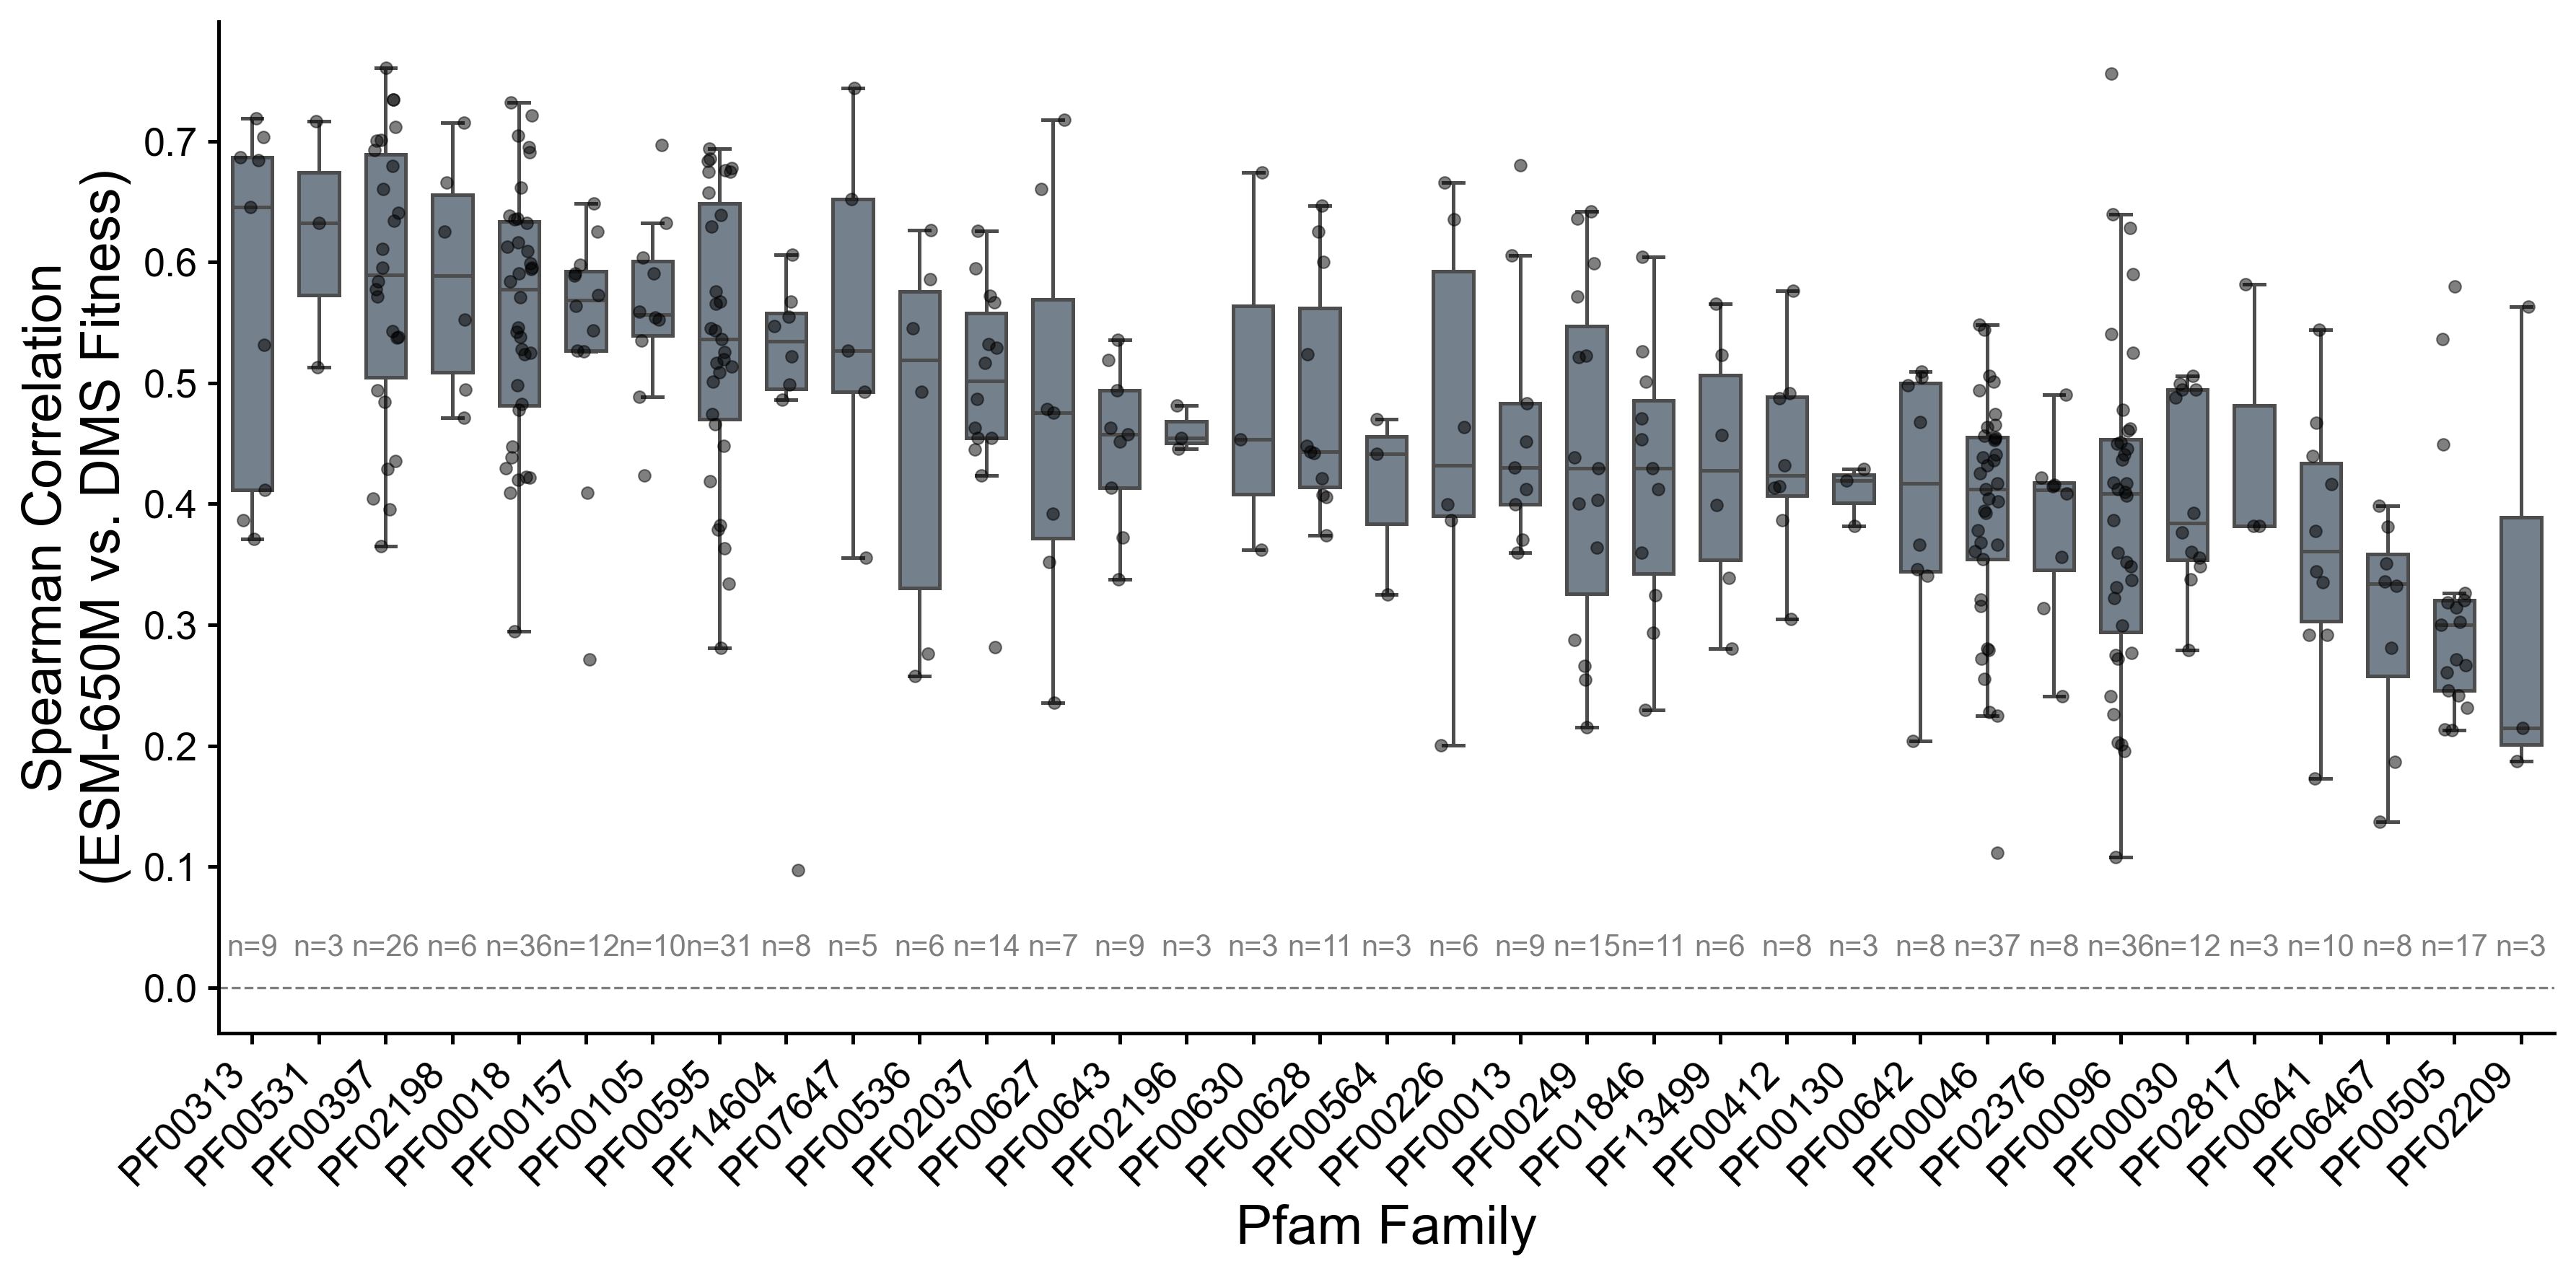

In [ ]:
"""import os
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ── Constants ─────────────────────────────────────────────────────────────────

DOMAIN_CSVS_DIR = "domain_csvs"
FIGURE_SIZE = (12, 6)
DPI = 300
FONT_SIZE_LABELS = 18
FONT_SIZE_TICKS = 13
FONT_SIZE_LEGEND = 13
FONT_SIZE_TITLE = 13
SPINE_WIDTH = 1.2
BOX_WIDTH = 0.6
BOX_LINEWIDTH = 1.2
STRIP_SIZE = 4
STRIP_ALPHA = 0.5
STRIP_JITTER = 0.2
MIN_DOMAINS = 3

arial_font = fm.FontProperties(fname="arial.ttf")

# ── Compute Spearman per domain ───────────────────────────────────────────────

records = []
domain_files = [f for f in os.listdir(DOMAIN_CSVS_DIR) if f.endswith(".csv")]

for fname in tqdm(domain_files, desc="Computing Spearman correlations"):
    parts = fname.replace(".csv", "").split("_")

    pfam_idx = next((i for i, p in enumerate(parts) if p.startswith("PF")), None)
    if pfam_idx is None:
        continue
    pfam = parts[pfam_idx]

    try:
        df = pd.read_csv(os.path.join(DOMAIN_CSVS_DIR, fname))
    except (pd.errors.EmptyDataError, Exception):
        continue

    if df.empty or "ESM_650M" not in df.columns or "normalized_fitness" not in df.columns:
        continue

    valid = df[["ESM_650M", "normalized_fitness"]].dropna()
    if len(valid) < 5:
        continue

    rho, _ = spearmanr(valid["ESM_650M"], valid["normalized_fitness"])
    records.append({"domain_id": fname.replace(".csv", ""), "pfam": pfam, "spearman": rho})

results_df = pd.DataFrame(records)
print(f"Computed correlations for {len(results_df)} domains across {results_df['pfam'].nunique()} Pfam families")

# ── Filter to families with enough domains ────────────────────────────────────

pfam_counts = results_df["pfam"].value_counts()
valid_pfams = pfam_counts[pfam_counts >= MIN_DOMAINS].index.tolist()
plot_df = results_df[results_df["pfam"].isin(valid_pfams)].copy()

pfam_order = (
    plot_df.groupby("pfam")["spearman"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)
plot_df["pfam"] = pd.Categorical(plot_df["pfam"], categories=pfam_order, ordered=True)

print(f"Plotting {len(valid_pfams)} Pfam families (>= {MIN_DOMAINS} domains each)")

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=FIGURE_SIZE, dpi=DPI)

sns.boxplot(
    data=plot_df,
    x="pfam",
    y="spearman",
    order=pfam_order,
    color="#708090",
    fliersize=0,
    width=BOX_WIDTH,
    linewidth=BOX_LINEWIDTH,
    ax=ax
)

sns.stripplot(
    data=plot_df,
    x="pfam",
    y="spearman",
    order=pfam_order,
    color="black",
    size=STRIP_SIZE,
    alpha=STRIP_ALPHA,
    jitter=STRIP_JITTER,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

# n= annotation below each pfam label
for i, pfam in enumerate(pfam_order):
    n = pfam_counts[pfam]
    ax.text(i, ax.get_ylim()[0] - 0.02, f"n={n}", ha="center", va="top",
            fontsize=10, fontproperties=arial_font, color="gray")

# Reference line at 0
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

# ── Axes and labels ───────────────────────────────────────────────────────────

ax.set_xlabel("Pfam Family", fontsize=FONT_SIZE_LABELS, fontproperties=arial_font)
ax.set_ylabel("Spearman Correlation\n(ESM-650M vs. DMS Fitness)", fontsize=FONT_SIZE_LABELS, fontproperties=arial_font)

for label in ax.get_xticklabels():
    label.set_fontproperties(arial_font)
    label.set_fontsize(FONT_SIZE_TICKS)
    label.set_rotation(45)
    label.set_ha("right")

for label in ax.get_yticklabels():
    label.set_fontproperties(arial_font)
    label.set_fontsize(FONT_SIZE_TICKS)

# ── Spines and ticks ──────────────────────────────────────────────────────────

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(SPINE_WIDTH)
    ax.spines[spine].set_color("black")

ax.tick_params(
    which="both",
    bottom=True, left=True, top=False, right=False,
    width=SPINE_WIDTH, color="black", labelsize=FONT_SIZE_TICKS
)

# ── Save ──────────────────────────────────────────────────────────────────────

plt.tight_layout()
plt.savefig("pfam_spearman_boxplot.svg", format="svg", dpi=DPI, bbox_inches="tight")
plt.savefig("pfam_spearman_boxplot.png", format="png", dpi=DPI, bbox_inches="tight")
plt.savefig("pfam_spearman_boxplot.pdf", format="pdf", dpi=DPI, bbox_inches="tight")

print("Saved: pfam_spearman_boxplot.svg/png/pdf")
plt.show()"""

# Model training

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from Bio import SeqIO
from transformers import EsmForMaskedLM, EsmTokenizer
from peft import LoraConfig, get_peft_model

In [ ]:
#@title Loss function
def listwise_ranking_loss(predicts, targets):
    """
    ListMLE loss for ranking tasks.

    Args:
        predicts: Predicted scores
        targets: Target scores

    Returns:
        Mean loss value
    """
    indices = targets.sort(descending=True, dim=-1).indices
    predicts = torch.gather(predicts, dim=1, index=indices)

    cumsums = predicts.exp().flip(dims=[1]).cumsum(dim=1).flip(dims=[1])
    loss = torch.log(cumsums + 1e-10) - predicts

    return loss.mean()

In [ ]:
#@title Finetuning for all domains
import torch
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from itertools import product
from transformers import EsmForMaskedLM, EsmTokenizer
from peft import LoraConfig, get_peft_model
from tqdm import tqdm
import logging
import warnings
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

# ── Constants ─────────────────────────────────────────────────────────────────

AA_ORDER        = ['L', 'A', 'G', 'V', 'S', 'E', 'R', 'T', 'I', 'D',
                   'P', 'K', 'Q', 'N', 'F', 'Y', 'M', 'H', 'W', 'C']
MODEL_NAME      = "facebook/esm2_t33_650M_UR50D"
DOMAIN_CSVS_DIR = "domain_csvs"
WILDTYPE_CSV    = "wildtype_sequences.csv"
OUTPUT_DIR      = "finetuned_models_v2"
MAX_LEN         = 1022
NUM_SAMPLES     = 20
MAX_EPOCHS      = 20
WEIGHT_DECAY    = 1e-2
LORA_DROPOUT    = 0.1
RANDOM_SEED     = 42

# ── Sweep Grid ────────────────────────────────────────────────────────────────

LR_VALUES     = [1e-4, 5e-4, 1e-3, 5e-3]
LORA_R_VALUES = [8, 16, 64, 128]

os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Helper Functions ──────────────────────────────────────────────────────────

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def truncate_to_domain(sequence, domain_start, domain_end, max_len=MAX_LEN):
    seq_len    = len(sequence)
    domain_mid = (domain_start + domain_end) // 2
    half       = max_len // 2
    start      = max(0, domain_mid - 1 - half)
    end        = start + max_len
    if end > seq_len:
        end   = seq_len
        start = max(0, end - max_len)
    return sequence[start:end], start


def get_LLR_scores(sequence, model, tokenizer, device):
    seq_list  = list(sequence)
    tokenized = tokenizer(sequence, padding=False, truncation=True,
                          max_length=1024, return_tensors="pt")
    input_ids = tokenized["input_ids"].to(device)

    logits    = model(input_ids).logits
    log_probs = torch.log_softmax(logits, dim=-1)
    wt_logits = log_probs[:, 1:-1, :].squeeze(0)

    wt_logits_df = pd.DataFrame(
        wt_logits[:, 4:24].cpu().detach().numpy(),
        columns=AA_ORDER,
        index=[f"{aa} {i+1}" for i, aa in enumerate(seq_list)]
    ).T

    wt_norm = np.diag(wt_logits_df.loc[[c.split(" ")[0] for c in wt_logits_df.columns]])
    LLR     = wt_logits_df - wt_norm
    return LLR, wt_logits, seq_list


def lookup_llr_scores(df, LLR, seq_offset):
    predicted = []
    for _, row in df.iterrows():
        if pd.isna(row["position"]) or pd.isna(row["wt_aa"]) or pd.isna(row["mut_aa"]):
            predicted.append(np.nan)
            continue
        col = f"{row['wt_aa']} {int(row['position']) - seq_offset}"
        mut = row["mut_aa"]
        try:
            predicted.append(LLR.loc[mut, col])
        except KeyError:
            predicted.append(np.nan)
    return predicted


def compute_loss_from_samples(df, seq_offset, num_samples, wt_logits, seq_list):
    valid_df = df.dropna(subset=["position", "wt_aa", "mut_aa", "normalized_fitness"])
    if len(valid_df) < 2:
        return None

    sample   = valid_df.sample(min(num_samples, len(valid_df)))
    pred_llr = []
    exp_fit  = []

    for _, row in sample.iterrows():
        pos    = int(row["position"]) - seq_offset - 1
        mut_aa = row["mut_aa"]
        wt_aa  = row["wt_aa"]
        if pos < 0 or pos >= wt_logits.shape[0]:
            continue
        if mut_aa not in AA_ORDER or wt_aa not in AA_ORDER:
            continue
        mut_idx    = AA_ORDER.index(mut_aa)
        wt_idx     = AA_ORDER.index(wt_aa)
        pred_score = wt_logits[pos, 4 + mut_idx] - wt_logits[pos, 4 + wt_idx]
        pred_llr.append(pred_score)
        exp_fit.append(float(row["normalized_fitness"]))

    if len(pred_llr) < 2:
        return None

    pred_tensor = torch.stack(pred_llr).unsqueeze(0)
    exp_tensor  = torch.tensor(exp_fit, dtype=torch.float32, device=device).unsqueeze(0)
    return listwise_ranking_loss(pred_tensor, exp_tensor)


def get_spearman(df, LLR, seq_offset):
    preds = lookup_llr_scores(df, LLR, seq_offset)
    valid = [(p, e) for p, e in zip(preds, df["normalized_fitness"]) if not np.isnan(p)]
    if not valid:
        return float("nan"), 0
    rho, _ = spearmanr(*zip(*valid))
    return rho, len(valid)


def build_lora_model(lora_r, lora_alpha):
    """Build a fresh ESM2 + LoRA model."""
    model       = EsmForMaskedLM.from_pretrained(MODEL_NAME)
    lora_config = LoraConfig(
        task_type      = "FEATURE_EXTRACTION",
        r              = lora_r,
        lora_alpha     = lora_alpha,
        target_modules = ["query", "key", "value", "output.dense"],
        lora_dropout   = LORA_DROPOUT,
    )
    model = get_peft_model(model, lora_config)
    for name, param in model.named_parameters():
        param.requires_grad = "lora" in name
    return model


def run_finetune(sequence, seq_offset, train_df, val_df, tokenizer,
                 lora_r, learning_rate, seed):
    set_seed(seed)
    model = build_lora_model(lora_r, lora_r * 2)
    model.to(device)

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=learning_rate, weight_decay=WEIGHT_DECAY
    )

    best_val_loss = float("inf")
    best_val_rho  = -float("inf")
    best_lora_state = None
    train_losses  = []
    val_losses    = []
    val_rhos      = []

    for epoch in range(1, MAX_EPOCHS + 1):

        model.train()
        _, wt_logits, seq_list = get_LLR_scores(sequence, model, tokenizer, device)
        train_loss = compute_loss_from_samples(train_df, seq_offset, NUM_SAMPLES,
                                               wt_logits, seq_list)
        if train_loss is None:
            continue

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        train_losses.append(train_loss.item())

        model.eval()
        with torch.no_grad():
            val_LLR, val_wt_logits, val_seq_list = get_LLR_scores(sequence, model,
                                                                    tokenizer, device)

        val_loss     = compute_loss_from_samples(val_df, seq_offset, NUM_SAMPLES,
                                                  val_wt_logits, val_seq_list)
        val_loss_val = val_loss.item() if val_loss is not None else float("nan")

        val_preds   = lookup_llr_scores(val_df, val_LLR, seq_offset)
        valid_pairs = [(p, e) for p, e in zip(val_preds, val_df["normalized_fitness"])
                       if not np.isnan(p)]
        val_rho     = spearmanr(*zip(*valid_pairs))[0] if valid_pairs else float("nan")

        val_losses.append(val_loss_val)
        val_rhos.append(val_rho)

        if val_loss_val < best_val_loss or val_rho > best_val_rho:
            best_val_loss = min(val_loss_val, best_val_loss)
            best_val_rho  = max(val_rho, best_val_rho)
            # Save only LoRA weights — ~10-50MB instead of ~2.5GB
            best_lora_state = {k: v.cpu().clone()
                               for k, v in model.state_dict().items()
                               if "lora_" in k}

        if len(val_losses) >= 3:
            loss_worse = val_losses[-1] > val_losses[-2] and val_losses[-2] > val_losses[-3]
            rho_worse  = val_rhos[-1]   < val_rhos[-2]   and val_rhos[-2]   < val_rhos[-3]
            if loss_worse or rho_worse:
                break

    del model
    torch.cuda.empty_cache()

    return best_lora_state, best_val_loss, best_val_rho, train_losses, val_losses, val_rhos


def save_sweep_plots(sweep_records, baseline, domain_id, domain_dir):

    # ── Val Spearman Curves ───────────────────────────────────────────────────

    n_lr   = len(LR_VALUES)
    colors = plt.cm.tab10(np.linspace(0, 1, len(LORA_R_VALUES)))

    fig, axes = plt.subplots(1, n_lr, figsize=(5 * n_lr, 5), dpi=150, sharey=True)
    if n_lr == 1:
        axes = [axes]

    for ax, lr in zip(axes, LR_VALUES):
        for color, lora_r in zip(colors, LORA_R_VALUES):
            record = next((r for r in sweep_records
                           if r["lr"] == lr and r["lora_r"] == lora_r), None)
            if record is None:
                continue
            epochs = list(range(1, len(record["val_rhos"]) + 1))
            ax.plot(epochs, record["val_rhos"], color=color, linewidth=2,
                    marker="o", markersize=4, label=f"r={lora_r}")

        ax.axhline(baseline.get("val", {}).get("spearman", 0), color="black",
                   linewidth=1, linestyle="--", alpha=0.5, label="Baseline")
        ax.set_title(f"lr = {lr:.0e}", fontsize=13)
        ax.set_xlabel("Epoch", fontsize=12)
        ax.legend(fontsize=10, frameon=False)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        for spine in ["left", "bottom"]:
            ax.spines[spine].set_linewidth(1.2)
        ax.tick_params(width=1.2)

    axes[0].set_ylabel("Val Spearman ρ", fontsize=12)
    plt.suptitle(f"{domain_id} — Sweep Val Spearman", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(domain_dir, "sweep_val_spearman.png"),
                dpi=150, bbox_inches="tight")
    plt.close()

    # ── Heatmap ───────────────────────────────────────────────────────────────

    rows = [{"lr": r["lr"], "lora_r": r["lora_r"], "best_val_rho": r["best_val_rho"]}
            for r in sweep_records]
    heatmap_data = pd.DataFrame(rows).pivot(index="lora_r", columns="lr",
                                            values="best_val_rho")

    fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
    im = ax.imshow(heatmap_data.values, cmap="RdYlGn", aspect="auto")
    plt.colorbar(im, ax=ax, label="Best Val Spearman ρ")

    ax.set_xticks(range(len(LR_VALUES)))
    ax.set_xticklabels([f"{lr:.0e}" for lr in heatmap_data.columns], fontsize=11)
    ax.set_yticks(range(len(LORA_R_VALUES)))
    ax.set_yticklabels(heatmap_data.index.astype(str), fontsize=11)
    ax.set_xlabel("Learning Rate", fontsize=13)
    ax.set_ylabel("LoRA Rank", fontsize=13)
    ax.set_title(f"{domain_id} — Sweep Heatmap", fontsize=13)

    for i in range(len(LORA_R_VALUES)):
        for j in range(len(LR_VALUES)):
            ax.text(j, i, f"{heatmap_data.values[i, j]:.3f}",
                    ha="center", va="center", fontsize=9, color="black")

    plt.tight_layout()
    plt.savefig(os.path.join(domain_dir, "sweep_heatmap.png"),
                dpi=150, bbox_inches="tight")
    plt.close()

    # ── Best Config Curves ────────────────────────────────────────────────────

    best_record = max(sweep_records, key=lambda r: r["best_val_rho"])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

    epochs = list(range(1, len(best_record["train_losses"]) + 1))
    ax1.plot(epochs, best_record["train_losses"], color="#708090", linewidth=2,
             marker="o", markersize=4, label="Train")
    ax1.plot(epochs, best_record["val_losses"], color="#d62728", linewidth=2,
             marker="o", markersize=4, label="Val")
    ax1.set_xlabel("Epoch", fontsize=12)
    ax1.set_ylabel("ListMLE Loss", fontsize=12)
    ax1.set_title(f"Best Config Loss\n(lr={best_record['lr']:.0e}, r={best_record['lora_r']})",
                  fontsize=11)
    ax1.legend(fontsize=10, frameon=False)

    ax2.plot(epochs, best_record["val_rhos"], color="#d62728", linewidth=2,
             marker="o", markersize=4, label="Val Spearman")
    ax2.axhline(baseline.get("val", {}).get("spearman", 0), color="black",
                linewidth=1, linestyle="--", alpha=0.5, label="Baseline")
    ax2.set_xlabel("Epoch", fontsize=12)
    ax2.set_ylabel("Spearman ρ", fontsize=12)
    ax2.set_title("Best Config Val Spearman", fontsize=11)
    ax2.legend(fontsize=10, frameon=False)

    for ax in [ax1, ax2]:
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        for spine in ["left", "bottom"]:
            ax.spines[spine].set_linewidth(1.2)
        ax.tick_params(width=1.2)

    plt.suptitle(f"{domain_id} — Best Config Curves", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(domain_dir, "best_config_curves.png"),
                dpi=150, bbox_inches="tight")
    plt.close()


# ── Load Shared Resources ─────────────────────────────────────────────────────

tokenizer    = EsmTokenizer.from_pretrained(MODEL_NAME)
wt_df        = pd.read_csv(WILDTYPE_CSV)
domain_files = sorted([f for f in os.listdir(DOMAIN_CSVS_DIR) if f.endswith(".csv")])

print(f"Found {len(domain_files)} domain CSVs\n")

master_log = []

# ── Main Loop Over Domains ────────────────────────────────────────────────────

for domain_fname in tqdm(domain_files, desc="Domains"):

    domain_id  = domain_fname.replace(".csv", "")
    domain_dir = os.path.join(OUTPUT_DIR, domain_id)

    if os.path.exists(os.path.join(domain_dir, "metadata.json")):
        tqdm.write(f"[SKIP] {domain_id} already completed")
        continue

    # ── Load CSV ──────────────────────────────────────────────────────────────

    try:
        df = pd.read_csv(os.path.join(DOMAIN_CSVS_DIR, domain_fname))
    except (pd.errors.EmptyDataError, Exception):
        tqdm.write(f"[SKIP] Could not read {domain_id}")
        continue

    df = df.dropna(subset=["normalized_fitness"]).reset_index(drop=True)
    if len(df) < 10:
        tqdm.write(f"[SKIP] {domain_id} — too few variants ({len(df)})")
        continue

    # ── Get Sequence ──────────────────────────────────────────────────────────

    uniprot_id = domain_id.split("_")[0]

    if uniprot_id in seq_dict:
        sequence = seq_dict[uniprot_id]
    else:
        wt_match = wt_df[wt_df["domain"] == domain_id]
        if wt_match.empty:
            tqdm.write(f"[SKIP] No sequence for {domain_id}")
            continue
        sequence = wt_match.iloc[0]["wt_seq"]

    # ── Truncate if Needed ────────────────────────────────────────────────────

    seq_offset = 0
    if len(sequence) > MAX_LEN:
        domain_start = int(df["position"].min())
        domain_end   = int(df["position"].max())
        sequence, seq_offset = truncate_to_domain(sequence, domain_start, domain_end)

    # ── Split ─────────────────────────────────────────────────────────────────

    set_seed(RANDOM_SEED)
    df       = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    n        = len(df)
    n_train  = int(0.20 * n)
    n_val    = int(0.40 * n)

    train_df = df.iloc[:n_train].reset_index(drop=True)
    val_df   = df.iloc[n_train:n_train + n_val].reset_index(drop=True)
    test_df  = df.iloc[n_train + n_val:].reset_index(drop=True)

    # ── Baseline ──────────────────────────────────────────────────────────────

    base_model = EsmForMaskedLM.from_pretrained(MODEL_NAME).to(device)
    base_model.eval()
    with torch.no_grad():
        base_LLR, _, _ = get_LLR_scores(sequence, base_model, tokenizer, device)
    del base_model
    torch.cuda.empty_cache()

    baseline = {}
    for split_name, split_df in [("full", df), ("val", val_df), ("test", test_df)]:
        rho, n_valid = get_spearman(split_df, base_LLR, seq_offset)
        baseline[split_name] = {"spearman": rho, "n": n_valid}

    # ── Hyperparameter Sweep ──────────────────────────────────────────────────

    sweep_records    = []
    best_sweep_rho   = -float("inf")
    best_sweep_state = None
    best_sweep_cfg   = None

    for lr, lora_r in product(LR_VALUES, LORA_R_VALUES):
        best_lora_state, best_val_loss, best_val_rho, train_losses, val_losses, val_rhos = run_finetune(
            sequence, seq_offset, train_df, val_df, tokenizer,
            lora_r=lora_r, learning_rate=lr, seed=RANDOM_SEED
        )

        sweep_records.append({
            "lr":            lr,
            "lora_r":        lora_r,
            "lora_alpha":    lora_r * 2,
            "best_val_loss": best_val_loss,
            "best_val_rho":  best_val_rho,
            "epochs_ran":    len(train_losses),
            "train_losses":  train_losses,
            "val_losses":    val_losses,
            "val_rhos":      val_rhos,
        })

        if best_val_rho > best_sweep_rho:
            best_sweep_rho   = best_val_rho
            best_sweep_state = best_lora_state
            best_sweep_cfg   = {"lr": lr, "lora_r": lora_r, "lora_alpha": lora_r * 2}

    # ── Save Sweep Plots ──────────────────────────────────────────────────────

    os.makedirs(domain_dir, exist_ok=True)
    save_sweep_plots(sweep_records, baseline, domain_id, domain_dir)

    # ── Evaluate Best Model on All Splits ─────────────────────────────────────

    best_model = build_lora_model(best_sweep_cfg["lora_r"], best_sweep_cfg["lora_alpha"])
    best_model.load_state_dict(best_sweep_state, strict=False)
    best_model.to(device)
    best_model.eval()

    with torch.no_grad():
        ft_LLR, _, _ = get_LLR_scores(sequence, best_model, tokenizer, device)

    ft_scores = {}
    for split_name, split_df in [("full", df), ("val", val_df), ("test", test_df)]:
        rho, n_valid = get_spearman(split_df, ft_LLR, seq_offset)
        ft_scores[split_name] = {"spearman": rho, "n": n_valid}

    # ── Save Outputs ──────────────────────────────────────────────────────────

    # 1. LoRA-only weights (~10-50MB vs ~2.5GB for full model)
    torch.save(best_sweep_state, os.path.join(domain_dir, "best_model_lora.pth"))

    # 2. Sweep results CSV
    sweep_df = pd.DataFrame([
        {k: v for k, v in r.items() if k not in ("train_losses", "val_losses", "val_rhos")}
        for r in sweep_records
    ]).sort_values("best_val_rho", ascending=False)
    sweep_df.to_csv(os.path.join(domain_dir, "sweep_results.csv"), index=False)

    # 3. Full sweep curves as JSON
    with open(os.path.join(domain_dir, "sweep_curves.json"), "w") as f:
        json.dump(sweep_records, f, indent=2)

    # 4. Metadata JSON
    metadata = {
        "domain_id":          domain_id,
        "uniprot_id":         uniprot_id,
        "seq_len":            len(sequence),
        "seq_offset":         seq_offset,
        "n_total":            n,
        "n_train":            n_train,
        "n_val":              n_val,
        "n_test":             n - n_train - n_val,
        "random_seed":        RANDOM_SEED,
        "best_config":        best_sweep_cfg,
        "baseline_spearman":  baseline,
        "finetuned_spearman": ft_scores,
        "delta_spearman": {
            split: ft_scores[split]["spearman"] - baseline[split]["spearman"]
            for split in ["full", "val", "test"]
        },
        "sweep_grid": {
            "lr_values":     LR_VALUES,
            "lora_r_values": LORA_R_VALUES,
            "max_epochs":    MAX_EPOCHS,
            "num_samples":   NUM_SAMPLES,
            "weight_decay":  WEIGHT_DECAY,
            "lora_dropout":  LORA_DROPOUT,
        }
    }
    with open(os.path.join(domain_dir, "metadata.json"), "w") as f:
        json.dump(metadata, f, indent=2)

    # ── Log to Master ─────────────────────────────────────────────────────────

    master_log.append({
        "domain_id":         domain_id,
        "uniprot_id":        uniprot_id,
        "n_variants":        n,
        "best_lr":           best_sweep_cfg["lr"],
        "best_lora_r":       best_sweep_cfg["lora_r"],
        "baseline_val_rho":  baseline["val"]["spearman"],
        "baseline_test_rho": baseline["test"]["spearman"],
        "ft_val_rho":        ft_scores["val"]["spearman"],
        "ft_test_rho":       ft_scores["test"]["spearman"],
        "delta_val_rho":     ft_scores["val"]["spearman"] - baseline["val"]["spearman"],
        "delta_test_rho":    ft_scores["test"]["spearman"] - baseline["test"]["spearman"],
    })

    # Save master log after every domain in case of crash
    pd.DataFrame(master_log).sort_values(
        "delta_test_rho", ascending=False
    ).to_csv(os.path.join(OUTPUT_DIR, "master_results.csv"), index=False)

    del best_model
    torch.cuda.empty_cache()

    tqdm.write(
        f"  ✓ {domain_id} | best: lr={best_sweep_cfg['lr']:.0e}, r={best_sweep_cfg['lora_r']} "
        f"| val ρ: {baseline['val']['spearman']:.3f} → {ft_scores['val']['spearman']:.3f} "
        f"| test ρ: {baseline['test']['spearman']:.3f} → {ft_scores['test']['spearman']:.3f}"
    )

# ── Final Summary ─────────────────────────────────────────────────────────────

master_df = pd.DataFrame(master_log).sort_values("delta_test_rho", ascending=False)
print(f"\n── Done ──")
print(f"Processed {len(master_log)} domains")
print(f"Mean Δ val ρ:  {master_df['delta_val_rho'].mean():.4f}")
print(f"Mean Δ test ρ: {master_df['delta_test_rho'].mean():.4f}")
print(f"Results saved to {OUTPUT_DIR}/")


# ── HOW TO RELOAD A SAVED MODEL ───────────────────────────────────────────────
#
# Each domain saves only the LoRA delta weights (~10-50MB) in best_model_lora.pth.
# To reload for inference on a new domain:
#
#   import json
#   import torch
#   from transformers import EsmForMaskedLM, EsmTokenizer
#   from peft import LoraConfig, get_peft_model
#
#   domain_dir = "finetuned_models/MY_DOMAIN_ID"
#
#   # 1. Load metadata to recover the saved config
#   with open(f"{domain_dir}/metadata.json") as f:
#       metadata = json.load(f)
#   cfg = metadata["best_config"]   # has lora_r, lora_alpha
#
#   # 2. Rebuild the base + LoRA architecture (same as training)
#   model = build_lora_model(cfg["lora_r"], cfg["lora_alpha"])
#
#   # 3. Load LoRA weights — strict=False fills base ESM2 weights from pretrained
#   lora_weights = torch.load(f"{domain_dir}/best_model_lora.pth")
#   model.load_state_dict(lora_weights, strict=False)
#
#   # 4. Ready for inference
#   model.to(device)
#   model.eval()
#   tokenizer = EsmTokenizer.from_pretrained("facebook/esm2_t33_650M_UR50D")
#   LLR, _, _ = get_LLR_scores(sequence, model, tokenizer, device)
#
# ─────────────────────────────────────────────────────────────────────────────

Using device: cuda


tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Found 522 domain CSVs



...

Domains: 100%|█████████▉| 520/522 [02:05<00:00,  4.46it/s]

[SKIP] Q9Y618_PF00249_613 already completed
[SKIP] Q9Y6N9_PF00595_207 already completed


Domains: 100%|██████████| 522/522 [02:05<00:00,  4.16it/s]

[SKIP] Q9Y6V0_PF05715_1058 already completed


KeyError: 'delta_test_rho'

Loading metadata: 100%|██████████| 516/516 [03:19<00:00,  2.59it/s]


Loaded 515 completed domains

── Best Config Distribution ──

Learning Rate:
  1e-04  █████████  98 (19.0%) ← EDGE
  5e-04  █████████████████  181 (35.1%)
  1e-03  █████████████████  184 (35.7%)
  5e-03  █████  52 (10.1%) ← EDGE

LoRA Rank:
  r=8     ███████████  123 (23.9%) ← EDGE
  r=16    ███████████  120 (23.3%)
  r=64    ███████████████  158 (30.7%)
  r=128   ███████████  114 (22.1%) ← EDGE

── Performance Gap (Best vs Worst Config) ──
  Mean gap:   0.3703
  Median gap: 0.3696
  Max gap:    0.7587
  % domains with gap > 0.05: 99.8%
  % domains with gap > 0.10: 99.0%

── Edge Analysis ──
  Best config at MAX lr  (5e-03): 52 / 515 (10.1%)
  Best config at MIN lr  (1e-04): 98 / 515 (19.0%)
  Best config at MAX rank (r=128): 114 / 515 (22.1%)
  Best config at MIN rank (r=8): 123 / 515 (23.9%)

  Recommendation:
  ⚠ >20% of domains peaked at max rank (r=128) — consider extending upward
  ⚠ >20% of domains peaked at min rank (r=8) — consider extending downward

── Sweep Benefit vs Fixed

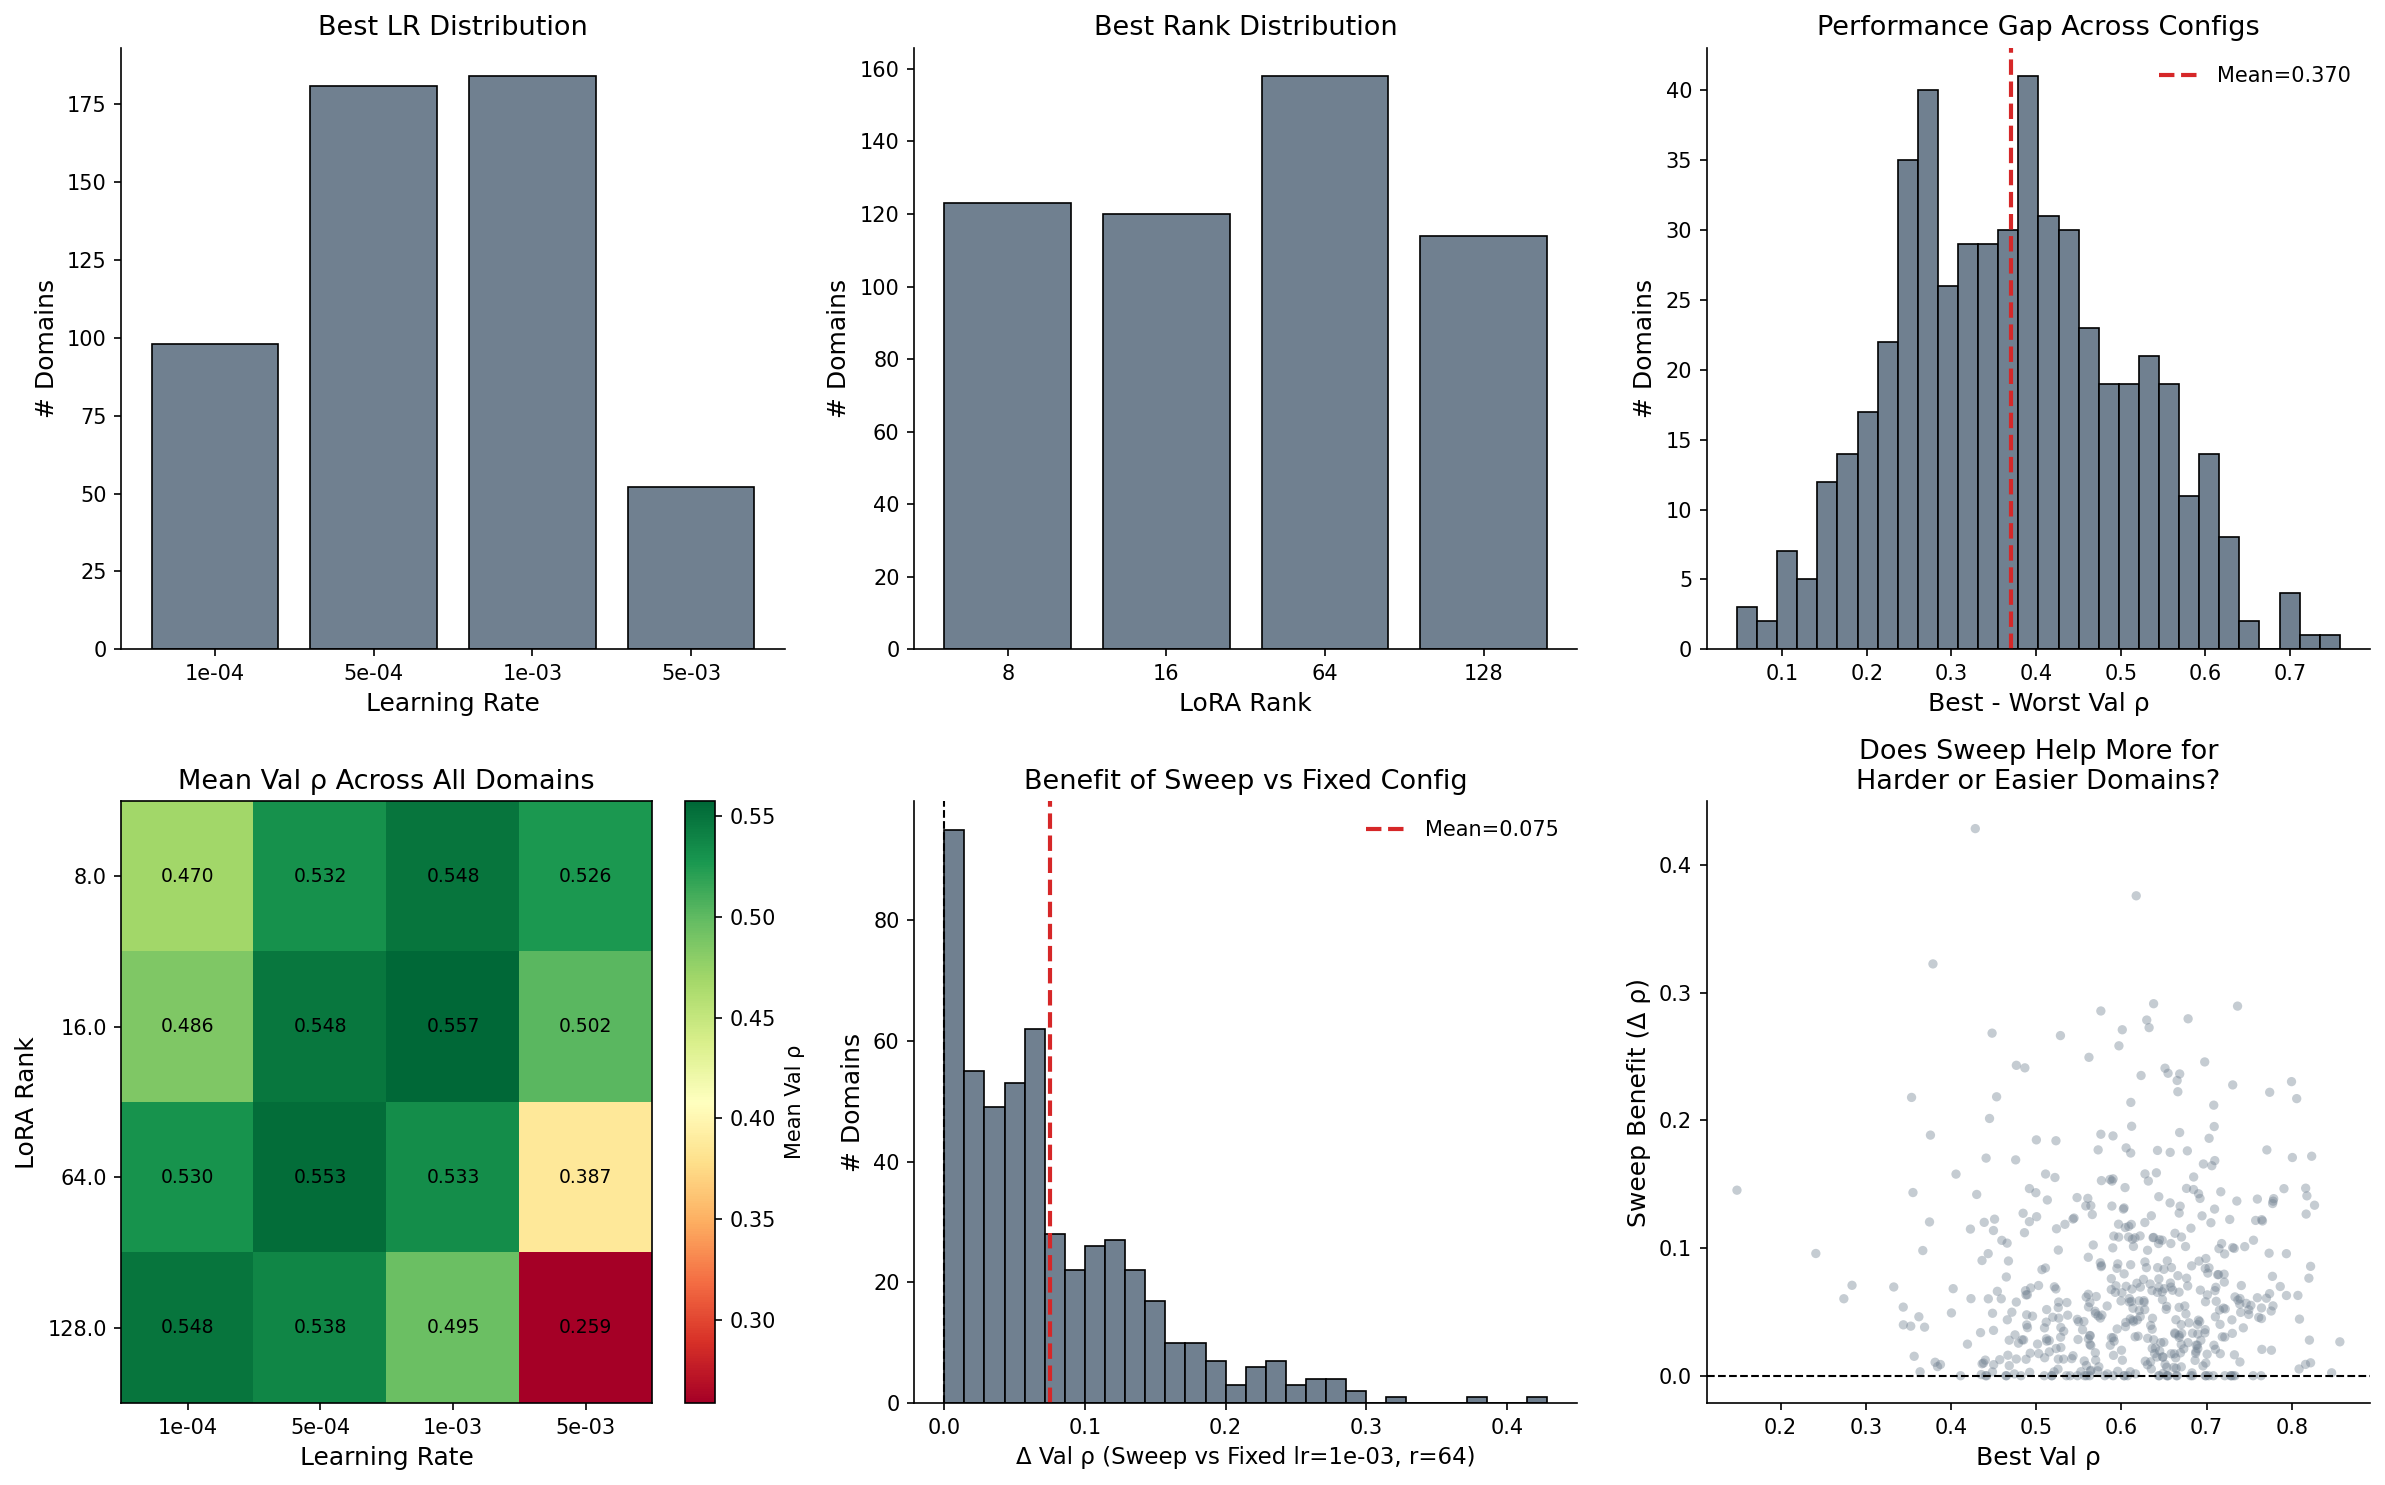


Saved: finetuned_models_v2/sweep_coverage_analysis.png


In [ ]:
#@title preliminary evaluation of hyperparams

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

OUTPUT_DIR = "finetuned_models_v2"


# ── Load All Metadata ─────────────────────────────────────────────────────────

records = []
for domain_id in tqdm(os.listdir(OUTPUT_DIR), desc="Loading metadata"):
    meta_path = os.path.join(OUTPUT_DIR, domain_id, "metadata.json")
    sweep_path = os.path.join(OUTPUT_DIR, domain_id, "sweep_results.csv")
    if not os.path.exists(meta_path) or not os.path.exists(sweep_path):
        continue
    with open(meta_path) as f:
        meta = json.load(f)
    sweep_df = pd.read_csv(sweep_path)
    records.append({"meta": meta, "sweep": sweep_df, "domain_id": domain_id})

print(f"Loaded {len(records)} completed domains")

# ── 1. Where Did the Best Config Land in the Grid? ───────────────────────────
# If the best config consistently lands at the edge of the grid,
# the optimum likely lies outside the range we searched.

best_lrs    = [r["meta"]["best_config"]["lr"]     for r in records]
best_ranks  = [r["meta"]["best_config"]["lora_r"] for r in records]

lr_values   = sorted(set(best_lrs))
rank_values = sorted(set(best_ranks))

lr_counts   = pd.Series(best_lrs).value_counts().sort_index()
rank_counts = pd.Series(best_ranks).value_counts().sort_index()

print("\n── Best Config Distribution ──")
print("\nLearning Rate:")
for lr, count in lr_counts.items():
    pct = 100 * count / len(records)
    bar = "█" * int(pct / 2)
    edge = " ← EDGE" if lr in [min(lr_values), max(lr_values)] else ""
    print(f"  {lr:.0e}  {bar}  {count} ({pct:.1f}%){edge}")

print("\nLoRA Rank:")
for rank, count in rank_counts.items():
    pct = 100 * count / len(records)
    bar = "█" * int(pct / 2)
    edge = " ← EDGE" if rank in [min(rank_values), max(rank_values)] else ""
    print(f"  r={rank:<4}  {bar}  {count} ({pct:.1f}%){edge}")

# ── 2. Performance Gap: Best vs Worst Config Per Domain ──────────────────────
# A large gap means the sweep mattered — configs varied a lot.
# A small gap means the landscape is flat and the grid coverage doesn't matter much.

gaps         = []
best_rhos    = []
worst_rhos   = []
second_rhos  = []

for r in records:
    sweep = r["sweep"].sort_values("best_val_rho", ascending=False)
    if len(sweep) < 2:
        continue
    best  = sweep.iloc[0]["best_val_rho"]
    worst = sweep.iloc[-1]["best_val_rho"]
    second = sweep.iloc[1]["best_val_rho"]
    gaps.append(best - worst)
    best_rhos.append(best)
    worst_rhos.append(worst)
    second_rhos.append(second)

gaps = np.array(gaps)
print(f"\n── Performance Gap (Best vs Worst Config) ──")
print(f"  Mean gap:   {gaps.mean():.4f}")
print(f"  Median gap: {np.median(gaps):.4f}")
print(f"  Max gap:    {gaps.max():.4f}")
print(f"  % domains with gap > 0.05: {100 * (gaps > 0.05).mean():.1f}%")
print(f"  % domains with gap > 0.10: {100 * (gaps > 0.10).mean():.1f}%")

# ── 3. Is the Best Config at the Edge? ───────────────────────────────────────
# If best LR == max LR or best rank == max rank for many domains,
# we're hitting the boundary and should extend the grid.

min_lr   = min(lr_values)
max_lr   = max(lr_values)
min_rank = min(rank_values)
max_rank = max(rank_values)

at_max_lr   = sum(1 for lr in best_lrs if lr == max_lr)
at_min_lr   = sum(1 for lr in best_lrs if lr == min_lr)
at_max_rank = sum(1 for r in best_ranks if r == max_rank)
at_min_rank = sum(1 for r in best_ranks if r == min_rank)

print(f"\n── Edge Analysis ──")
print(f"  Best config at MAX lr  ({max_lr:.0e}): {at_max_lr} / {len(records)} ({100*at_max_lr/len(records):.1f}%)")
print(f"  Best config at MIN lr  ({min_lr:.0e}): {at_min_lr} / {len(records)} ({100*at_min_lr/len(records):.1f}%)")
print(f"  Best config at MAX rank (r={max_rank}): {at_max_rank} / {len(records)} ({100*at_max_rank/len(records):.1f}%)")
print(f"  Best config at MIN rank (r={min_rank}): {at_min_rank} / {len(records)} ({100*at_min_rank/len(records):.1f}%)")

EDGE_THRESHOLD = 0.20
print(f"\n  Recommendation:")
if at_max_lr / len(records) > EDGE_THRESHOLD:
    print(f"  ⚠ >20% of domains peaked at max LR ({max_lr:.0e}) — consider extending upward")
if at_min_lr / len(records) > EDGE_THRESHOLD:
    print(f"  ⚠ >20% of domains peaked at min LR ({min_lr:.0e}) — consider extending downward")
if at_max_rank / len(records) > EDGE_THRESHOLD:
    print(f"  ⚠ >20% of domains peaked at max rank (r={max_rank}) — consider extending upward")
if at_min_rank / len(records) > EDGE_THRESHOLD:
    print(f"  ⚠ >20% of domains peaked at min rank (r={min_rank}) — consider extending downward")
if all(v / len(records) <= EDGE_THRESHOLD
       for v in [at_max_lr, at_min_lr, at_max_rank, at_min_rank]):
    print(f"  ✓ Grid coverage looks good — best configs are not clustering at edges")

# ── 4. Val Rho Improvement from Sweep vs Fixed Config ────────────────────────
# How much did the sweep actually help vs just using the modal best config?

modal_lr   = lr_counts.idxmax()
modal_rank = rank_counts.idxmax()

fixed_rhos = []
for r in records:
    sweep = r["sweep"]
    match = sweep[(sweep["lr"] == modal_lr) & (sweep["lora_r"] == modal_rank)]
    if not match.empty:
        fixed_rhos.append(match.iloc[0]["best_val_rho"])

best_rhos_arr  = np.array(best_rhos)
fixed_rhos_arr = np.array(fixed_rhos)
sweep_benefit  = best_rhos_arr[:len(fixed_rhos_arr)] - fixed_rhos_arr

print(f"\n── Sweep Benefit vs Fixed Config (lr={modal_lr:.0e}, r={modal_rank}) ──")
print(f"  Mean val ρ with sweep:        {best_rhos_arr[:len(fixed_rhos_arr)].mean():.4f}")
print(f"  Mean val ρ with fixed config: {fixed_rhos_arr.mean():.4f}")
print(f"  Mean benefit of sweep:        {sweep_benefit.mean():.4f}")
print(f"  % domains where sweep helped by > 0.02: {100*(sweep_benefit > 0.02).mean():.1f}%")
print(f"  % domains where sweep helped by > 0.05: {100*(sweep_benefit > 0.05).mean():.1f}%")

# ── 5. Plots ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 10), dpi=150)

# 5a. Best LR distribution
ax = axes[0, 0]
ax.bar([f"{lr:.0e}" for lr in lr_counts.index], lr_counts.values, color="#708090", edgecolor="black", linewidth=0.8)
ax.set_xlabel("Learning Rate", fontsize=12)
ax.set_ylabel("# Domains", fontsize=12)
ax.set_title("Best LR Distribution", fontsize=13)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# 5b. Best rank distribution
ax = axes[0, 1]
ax.bar([str(r) for r in rank_counts.index], rank_counts.values, color="#708090", edgecolor="black", linewidth=0.8)
ax.set_xlabel("LoRA Rank", fontsize=12)
ax.set_ylabel("# Domains", fontsize=12)
ax.set_title("Best Rank Distribution", fontsize=13)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# 5c. Performance gap distribution
ax = axes[0, 2]
ax.hist(gaps, bins=30, color="#708090", edgecolor="black", linewidth=0.8)
ax.axvline(gaps.mean(), color="#d62728", linewidth=2, linestyle="--", label=f"Mean={gaps.mean():.3f}")
ax.set_xlabel("Best - Worst Val ρ", fontsize=12)
ax.set_ylabel("# Domains", fontsize=12)
ax.set_title("Performance Gap Across Configs", fontsize=13)
ax.legend(fontsize=10, frameon=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# 5d. Heatmap: mean best val rho per (lr, rank) across all domains
ax = axes[1, 0]
grid_data = []
for r in records:
    for _, row in r["sweep"].iterrows():
        grid_data.append({"lr": row["lr"], "lora_r": row["lora_r"],
                          "best_val_rho": row["best_val_rho"]})
grid_df      = pd.DataFrame(grid_data)
heatmap_mean = grid_df.groupby(["lora_r", "lr"])["best_val_rho"].mean().unstack()

im = ax.imshow(heatmap_mean.values, cmap="RdYlGn", aspect="auto")
plt.colorbar(im, ax=ax, label="Mean Val ρ")
ax.set_xticks(range(len(heatmap_mean.columns)))
ax.set_xticklabels([f"{lr:.0e}" for lr in heatmap_mean.columns], fontsize=10)
ax.set_yticks(range(len(heatmap_mean.index)))
ax.set_yticklabels(heatmap_mean.index.astype(str), fontsize=10)
ax.set_xlabel("Learning Rate", fontsize=12)
ax.set_ylabel("LoRA Rank", fontsize=12)
ax.set_title("Mean Val ρ Across All Domains", fontsize=13)
for i in range(len(heatmap_mean.index)):
    for j in range(len(heatmap_mean.columns)):
        ax.text(j, i, f"{heatmap_mean.values[i, j]:.3f}",
                ha="center", va="center", fontsize=9)

# 5e. Sweep benefit distribution
ax = axes[1, 1]
ax.hist(sweep_benefit, bins=30, color="#708090", edgecolor="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.axvline(sweep_benefit.mean(), color="#d62728", linewidth=2, linestyle="--",
           label=f"Mean={sweep_benefit.mean():.3f}")
ax.set_xlabel(f"Δ Val ρ (Sweep vs Fixed lr={modal_lr:.0e}, r={modal_rank})", fontsize=11)
ax.set_ylabel("# Domains", fontsize=12)
ax.set_title("Benefit of Sweep vs Fixed Config", fontsize=13)
ax.legend(fontsize=10, frameon=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# 5f. Best val rho vs delta from sweep
ax = axes[1, 2]
ax.scatter(best_rhos_arr[:len(fixed_rhos_arr)], sweep_benefit,
           alpha=0.4, s=20, color="#708090", edgecolor="none")
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Best Val ρ", fontsize=12)
ax.set_ylabel("Sweep Benefit (Δ ρ)", fontsize=12)
ax.set_title("Does Sweep Help More for\nHarder or Easier Domains?", fontsize=13)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sweep_coverage_analysis.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSaved: {OUTPUT_DIR}/sweep_coverage_analysis.png")

# Data Analysis

In [ ]:
#@title EDA
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import defaultdict
from tqdm import tqdm

DOMAIN_CSVS_DIR = "domain_csvs"
OUTPUT_DIR      = "eda_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Palette ───────────────────────────────────────────────────────────────────
C_BASE   = "#708090"
C_ACCENT = "#d62728"
C_BLUE   = "#3266ad"
C_MED    = "#5b8dd9"

# ── Load all domain CSVs ──────────────────────────────────────────────────────

domain_files = sorted([f for f in os.listdir(DOMAIN_CSVS_DIR) if f.endswith(".csv")])
print(f"Found {len(domain_files)} domain CSVs")

records = []
for fname in tqdm(domain_files, desc="Loading CSVs"):
    parts     = fname.replace(".csv", "").split("_")
    uniprot   = parts[0]
    pfam      = parts[1] if len(parts) > 1 else "unknown"
    domain_id = fname.replace(".csv", "")
    try:
        df = pd.read_csv(os.path.join(DOMAIN_CSVS_DIR, fname))
        df = df.dropna(subset=["normalized_fitness"])
        if df.empty:
            continue
        seq_len = len(str(df["aa_seq"].iloc[0])) if "aa_seq" in df.columns else np.nan
        records.append({
            "domain_id":         domain_id,
            "uniprot_id":        uniprot,
            "pfam_id":           pfam,
            "n_variants":        len(df),
            "seq_len":           seq_len,
            "fitness_vals":      df["normalized_fitness"].values,
        })
    except Exception as e:
        print(f"[SKIP] {fname}: {e}")

meta_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "fitness_vals"}
    for r in records
])

print(f"Loaded {len(meta_df)} domains")
print(f"Unique UniProt IDs: {meta_df['uniprot_id'].nunique()}")
print(f"Unique Pfam families: {meta_df['pfam_id'].nunique()}")

# ── Pfam domain counts ────────────────────────────────────────────────────────

pfam_counts = meta_df["pfam_id"].value_counts()
single_pfams = pfam_counts[pfam_counts == 1]
multi_pfams  = pfam_counts[pfam_counts > 1].sort_values(ascending=False)

print(f"\nPfam families with only 1 domain: {len(single_pfams)}")
print(f"Pfam families with >1 domain:      {len(multi_pfams)}")

# ── Top 10 Pfam for violin ────────────────────────────────────────────────────

top10_pfams = pfam_counts.head(10).index.tolist()

# ── All fitness values ────────────────────────────────────────────────────────

all_fitness = np.concatenate([r["fitness_vals"] for r in records])

# ─────────────────────────────────────────────────────────────────────────────
# Figure 1: Bar graph — domains per Pfam (multi-member only)
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 5), dpi=150)

x     = np.arange(len(multi_pfams))
bars  = ax.bar(x, multi_pfams.values, color=C_BASE, edgecolor="none", linewidth=0)

ax.set_xticks(x)
ax.set_xticklabels(multi_pfams.index, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Number of domains", fontsize=12)
ax.set_xlabel("Pfam family", fontsize=12)

# Total domains annotation top-right
ax.text(0.98, 0.97,
        f"Total domains: {len(meta_df)}\nSingle-member Pfam families: {len(single_pfams)}",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=10, color="#444",
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#ccc", lw=0.8))

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(1.0)
ax.tick_params(width=1.0)

plt.title("Domains per Pfam family (multi-member families only)", fontsize=13, pad=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig1_pfam_bar.png"), dpi=150, bbox_inches="tight")
plt.close()
print("Saved fig1_pfam_bar.png")

# ─────────────────────────────────────────────────────────────────────────────
# Figure 2: Histogram — variants per domain
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

counts = meta_df["n_variants"].values
ax.hist(counts, bins=50, color=C_BASE, edgecolor="none")
ax.axvline(np.median(counts), color=C_ACCENT, linewidth=1.8,
           linestyle="--", label=f"Median: {np.median(counts):.0f}")
ax.axvline(np.mean(counts), color=C_BLUE, linewidth=1.8,
           linestyle="--", label=f"Mean: {np.mean(counts):.0f}")

ax.set_xlabel("Number of variants", fontsize=12)
ax.set_ylabel("Number of domains", fontsize=12)
ax.set_title("Distribution of variants per domain", fontsize=13)
ax.legend(fontsize=10, frameon=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig2_variants_hist.png"), dpi=150, bbox_inches="tight")
plt.close()
print("Saved fig2_variants_hist.png")

# ─────────────────────────────────────────────────────────────────────────────
# Figure 3: Histogram — domain sequence lengths
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

lengths = meta_df["seq_len"].dropna().values
ax.hist(lengths, bins=50, color=C_BASE, edgecolor="none")
ax.axvline(np.median(lengths), color=C_ACCENT, linewidth=1.8,
           linestyle="--", label=f"Median: {np.median(lengths):.0f} aa")
ax.axvline(np.mean(lengths), color=C_BLUE, linewidth=1.8,
           linestyle="--", label=f"Mean: {np.mean(lengths):.0f} aa")

ax.set_xlabel("Domain sequence length (aa)", fontsize=12)
ax.set_ylabel("Number of domains", fontsize=12)
ax.set_title("Distribution of domain sequence lengths", fontsize=13)
ax.legend(fontsize=10, frameon=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig3_seq_len_hist.png"), dpi=150, bbox_inches="tight")
plt.close()
print("Saved fig3_seq_len_hist.png")

# ─────────────────────────────────────────────────────────────────────────────
# Figure 4: Violin plots — normalized fitness
# All variants + top 10 Pfam families
# ─────────────────────────────────────────────────────────────────────────────

# Build data list: [all] + [top10 pfams]
violin_data   = [all_fitness]
violin_labels = ["All domains"]
violin_ns     = [len(all_fitness)]

for pfam in top10_pfams:
    pfam_fitness = np.concatenate([
        r["fitness_vals"] for r in records if r["pfam_id"] == pfam
    ])
    violin_data.append(pfam_fitness)
    violin_labels.append(pfam)
    violin_ns.append(len(pfam_fitness))

fig, ax = plt.subplots(figsize=(16, 6), dpi=150)

parts = ax.violinplot(violin_data, positions=range(len(violin_data)),
                      showmedians=True, showextrema=False, widths=0.7)

# Style violins
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(C_ACCENT if i == 0 else C_MED)
    pc.set_alpha(0.65)
    pc.set_edgecolor("none")

parts["cmedians"].set_color("white")
parts["cmedians"].set_linewidth(1.5)

# Add n= labels below x-axis
for i, (label, n) in enumerate(zip(violin_labels, violin_ns)):
    ax.text(i, ax.get_ylim()[0] - 0.02,
            f"n={n:,}", ha="center", va="top", fontsize=8, color="#666",
            transform=ax.get_xaxis_transform())

ax.set_xticks(range(len(violin_labels)))
ax.set_xticklabels(violin_labels, rotation=30, ha="right", fontsize=10)
ax.set_ylabel("Normalized fitness", fontsize=12)
ax.set_title("Distribution of normalized fitness — all domains and top 10 Pfam families",
             fontsize=13)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=C_ACCENT, alpha=0.65, label="All domains"),
    Patch(facecolor=C_MED,    alpha=0.65, label="Individual Pfam"),
]
ax.legend(handles=legend_elements, fontsize=10, frameon=False, loc="upper right")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig4_fitness_violins.png"), dpi=150, bbox_inches="tight")
plt.close()
print("Saved fig4_fitness_violins.png")

# ─────────────────────────────────────────────────────────────────────────────
# Summary stats printout
# ─────────────────────────────────────────────────────────────────────────────

print("\n── Summary Statistics ──")
print(f"  Total domains:              {len(meta_df)}")
print(f"  Unique UniProt IDs:         {meta_df['uniprot_id'].nunique()}")
print(f"  Unique Pfam families:       {meta_df['pfam_id'].nunique()}")
print(f"  Single-member Pfam families:{len(single_pfams)}")
print(f"  Total variants:             {len(all_fitness):,}")
print(f"  Variants/domain — mean:     {meta_df['n_variants'].mean():.1f}")
print(f"  Variants/domain — median:   {meta_df['n_variants'].median():.0f}")
print(f"  Seq length — mean:          {np.nanmean(lengths):.1f} aa")
print(f"  Seq length — median:        {np.nanmedian(lengths):.0f} aa")
print(f"  Fitness — mean:             {all_fitness.mean():.4f}")
print(f"  Fitness — std:              {all_fitness.std():.4f}")
print(f"\nSingle-member Pfam families:")
for pfam in single_pfams.index:
    print(f"  {pfam}")

Found 522 domain CSVs


Loading CSVs:  18%|█▊        | 96/522 [00:24<01:08,  6.22it/s]

[SKIP] P02640_PF02209_792.csv: No columns to parse from file


Loading CSVs: 100%|██████████| 522/522 [02:16<00:00,  3.82it/s]


Loaded 521 domains
Unique UniProt IDs: 434
Unique Pfam families: 127

Pfam families with only 1 domain: 67
Pfam families with >1 domain:      60
Saved fig1_pfam_bar.png
Saved fig2_variants_hist.png
Saved fig3_seq_len_hist.png
Saved fig4_fitness_violins.png

── Summary Statistics ──
  Total domains:              521
  Unique UniProt IDs:         434
  Unique Pfam families:       127
  Single-member Pfam families:67
  Total variants:             562,871
  Variants/domain — mean:     1080.4
  Variants/domain — median:   1092
  Seq length — mean:          57.7 aa
  Seq length — median:        58 aa
  Fitness — mean:             -0.3184
  Fitness — std:              0.3857

Single-member Pfam families:
  PF06220
  PF01480
  PF17035
  PF00831
  PF00538
  PF00533
  PF02270
  PF04564
  PF01281
  PF01023
  PF01381
  PF18366
  PF00240
  PF08313
  PF00779
  PF10650
  PF00173
  PF05129
  PF05741
  PF02172
  PF16558
  PF02008
  PF16557
  PF03671
  PF01111
  PF04855
  PF18016
  PF00789
  PF16577
  P

In [ ]:
#@title Cross-domain evaluation — family-stratified + inter-family matrices

import os
import json
import gzip
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from Bio import SeqIO
from transformers import EsmForMaskedLM, EsmTokenizer
from peft import LoraConfig, get_peft_model
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# ── Constants ─────────────────────────────────────────────────────────────────

MODEL_NAME      = "facebook/esm2_t33_650M_UR50D"
MODELS_DIR      = "finetuned_models_v2"
DOMAIN_CSVS_DIR = "domain_csvs"
WILDTYPE_CSV    = "wildtype_sequences.csv"
UNIPROT_FASTA   = "../InterPLM/datafiles/uniprot/uniprot_sprot.fasta.gz"
SUPP_TABLE      = "SupplementaryTable2.txt"
OUTPUT_DIR      = "cross_domain_eval"
CHECKPOINT_FILE = os.path.join(OUTPUT_DIR, "cross_domain_checkpoint.csv")
INTER_FAMILY_CHECKPOINT = os.path.join(OUTPUT_DIR, "inter_family_checkpoint.csv")
MAX_LEN         = 1022
AA_ORDER        = ['L','A','G','V','S','E','R','T','I','D',
                   'P','K','Q','N','F','Y','M','H','W','C']
MIN_FAMILY_SIZE = 5
RANDOM_SEED     = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Build seq_dict from UniProt FASTA (full proteins) ────────────────────────

print("Building seq_dict from UniProt FASTA...")
df_sup     = pd.read_csv(SUPP_TABLE, sep="\t")
target_ids = set(df_sup["uniprot_ID"].dropna().unique())

seq_dict = {}
with gzip.open(UNIPROT_FASTA, "rt") as f:
    for record in SeqIO.parse(f, "fasta"):
        uniprot_id = record.id.split("|")[1]
        if uniprot_id in target_ids:
            seq_dict[uniprot_id] = str(record.seq)

print(f"seq_dict built: {len(seq_dict)} UniProt entries (full proteins)")

# ── Load wildtype CSV (fallback only — contains domain slices) ────────────────

wt_df = pd.read_csv(WILDTYPE_CSV)

# ── Load all domain metadata ──────────────────────────────────────────────────

print("Loading domain metadata...")
all_meta = {}
for domain_id in os.listdir(MODELS_DIR):
    meta_path = os.path.join(MODELS_DIR, domain_id, "metadata.json")
    lora_path = os.path.join(MODELS_DIR, domain_id, "best_model_lora.pth")
    if not os.path.exists(meta_path) or not os.path.exists(lora_path):
        continue
    with open(meta_path) as f:
        meta = json.load(f)
    all_meta[domain_id] = meta

print(f"Found {len(all_meta)} completed domains with LoRA weights")

# ── Build Pfam family index ───────────────────────────────────────────────────

pfam_to_domains = {}
for domain_id, meta in all_meta.items():
    pfam = domain_id.split("_")[1] if "_" in domain_id else "unknown"
    pfam_to_domains.setdefault(pfam, []).append(domain_id)

qualifying_families = {
    pfam: domains
    for pfam, domains in pfam_to_domains.items()
    if len(domains) >= MIN_FAMILY_SIZE
}
print(f"Pfam families with >= {MIN_FAMILY_SIZE} members: {len(qualifying_families)}")

# ── Helper: build LoRA model ──────────────────────────────────────────────────

def build_lora_model(lora_r, lora_alpha):
    model = EsmForMaskedLM.from_pretrained(MODEL_NAME)
    lora_config = LoraConfig(
        task_type      = "FEATURE_EXTRACTION",
        r              = lora_r,
        lora_alpha     = lora_alpha,
        target_modules = ["query", "key", "value", "output.dense"],
        lora_dropout   = 0.1,
    )
    model = get_peft_model(model, lora_config)
    for name, param in model.named_parameters():
        param.requires_grad = "lora" in name
    return model


def truncate_to_domain(sequence, domain_start, domain_end, max_len=MAX_LEN):
    seq_len    = len(sequence)
    domain_mid = (domain_start + domain_end) // 2
    half       = max_len // 2
    start      = max(0, domain_mid - 1 - half)
    end        = start + max_len
    if end > seq_len:
        end   = seq_len
        start = max(0, end - max_len)
    return sequence[start:end], start


def get_LLR_scores(sequence, model, tokenizer, device):
    seq_list  = list(sequence)
    tokenized = tokenizer(sequence, padding=False, truncation=True,
                          max_length=1024, return_tensors="pt")
    input_ids = tokenized["input_ids"].to(device)
    with torch.no_grad():
        logits    = model(input_ids).logits
    log_probs = torch.log_softmax(logits, dim=-1)
    wt_logits = log_probs[:, 1:-1, :].squeeze(0)
    wt_logits_df = pd.DataFrame(
        wt_logits[:, 4:24].cpu().detach().numpy(),
        columns=AA_ORDER,
        index=[f"{aa} {i+1}" for i, aa in enumerate(seq_list)]
    ).T
    wt_norm = np.diag(wt_logits_df.loc[[c.split(" ")[0] for c in wt_logits_df.columns]])
    LLR     = wt_logits_df - wt_norm
    return LLR, wt_logits, seq_list


def get_spearman_from_llr(df, LLR, seq_offset):
    preds = []
    for _, row in df.iterrows():
        if pd.isna(row["position"]) or pd.isna(row["wt_aa"]) or pd.isna(row["mut_aa"]):
            preds.append(np.nan)
            continue
        col = f"{row['wt_aa']} {int(row['position']) - seq_offset}"
        mut = row["mut_aa"]
        try:
            preds.append(LLR.loc[mut, col])
        except KeyError:
            preds.append(np.nan)
    valid = [(p, e) for p, e in zip(preds, df["normalized_fitness"])
             if not np.isnan(p) and not np.isnan(e)]
    if len(valid) < 5:
        return np.nan
    rho, _ = spearmanr(*zip(*valid))
    return rho


def load_domain_data(domain_id, meta):
    csv_path = os.path.join(DOMAIN_CSVS_DIR, f"{domain_id}.csv")
    if not os.path.exists(csv_path):
        return None
    try:
        df = pd.read_csv(csv_path).dropna(subset=["normalized_fitness"])
    except Exception:
        return None
    if len(df) < 5:
        return None

    domain_start = int(df["position"].min())
    domain_end   = int(df["position"].max())
    uniprot_id   = domain_id.split("_")[0]

    if uniprot_id in seq_dict:
        # Full protein from FASTA — same as training
        sequence = seq_dict[uniprot_id]
        if len(sequence) > MAX_LEN:
            sequence, seq_offset = truncate_to_domain(sequence, domain_start, domain_end)
        else:
            seq_offset = 0
    else:
        # Fallback: wt_df contains domain slice, not full protein
        wt_match = wt_df[wt_df["domain"] == domain_id]
        if wt_match.empty:
            return None
        sequence   = wt_match.iloc[0]["wt_seq"]
        seq_offset = domain_start - 1

    df      = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    n       = len(df)
    n_train = int(0.20 * n)
    n_val   = int(0.40 * n)
    test_df = df.iloc[n_train + n_val:].reset_index(drop=True)

    if len(test_df) < 5:
        return None

    return sequence, seq_offset, test_df


def get_baseline_rho(domain_id, meta):
    try:
        return meta["baseline_spearman"]["test"]["spearman"]
    except (KeyError, TypeError):
        return np.nan


tokenizer = EsmTokenizer.from_pretrained(MODEL_NAME)

# ── Diagnostic ────────────────────────────────────────────────────────────────

print("\nDiagnosing load_domain_data on first 5 domains...")
print(f"wt_df columns: {list(wt_df.columns)}")
print(f"wt_df sample:\n{wt_df.head(3)}\n")
sample_domains = list(all_meta.keys())[:5]
for d in sample_domains:
    result = load_domain_data(d, all_meta[d])
    if result is not None:
        seq, offset, tdf = result
        print(f"  {d}: seq_len={len(seq)}, offset={offset}, test_rows={len(tdf)}")
    else:
        print(f"  {d}: FAILED")

# ─────────────────────────────────────────────────────────────────────────────
# PART 1: Family-stratified cross-domain matrices
# ─────────────────────────────────────────────────────────────────────────────

if os.path.exists(CHECKPOINT_FILE):
    ckpt_df        = pd.read_csv(CHECKPOINT_FILE)
    if "pfam" not in ckpt_df.columns:
        ckpt_df["pfam"] = ckpt_df["model_domain"].apply(
            lambda x: x.split("_")[1] if len(x.split("_")) > 1 else "unknown"
        )
    completed_keys = set(zip(ckpt_df["model_domain"], ckpt_df["target_domain"]))
    results_rows   = ckpt_df.to_dict("records")
    print(f"Resuming from checkpoint: {len(results_rows)} pairs already done")
else:
    completed_keys = set()
    results_rows   = []

for pfam, family_domains in tqdm(qualifying_families.items(), desc="Families"):

    expected_pairs = len(family_domains) ** 2
    family_done    = sum(
        1 for (m, t) in completed_keys
        if m in family_domains and t in family_domains
    )
    if family_done == expected_pairs:
        continue

    family_data = {}
    for domain_id in family_domains:
        result = load_domain_data(domain_id, all_meta[domain_id])
        if result is not None:
            family_data[domain_id] = result

    valid_domains = list(family_data.keys())
    if len(valid_domains) < 2:
        continue

    for model_domain in tqdm(valid_domains, desc=f"{pfam}", leave=False):
        targets_needed = [t for t in valid_domains
                          if (model_domain, t) not in completed_keys]
        if not targets_needed:
            continue

        meta      = all_meta[model_domain]
        cfg       = meta["best_config"]
        lora_path = os.path.join(MODELS_DIR, model_domain, "best_model_lora.pth")

        try:
            model = build_lora_model(cfg["lora_r"], cfg["lora_alpha"])
            lora_weights = torch.load(lora_path, map_location="cpu")
            model.load_state_dict(lora_weights, strict=False)
            model.to(device)
            model.eval()
        except Exception as e:
            tqdm.write(f"  [SKIP] Could not load model {model_domain}: {e}")
            continue

        for target_domain in targets_needed:
            sequence, seq_offset, test_df = family_data[target_domain]
            baseline_rho = get_baseline_rho(target_domain, all_meta[target_domain])

            try:
                LLR, _, _ = get_LLR_scores(sequence, model, tokenizer, device)
                ft_rho    = get_spearman_from_llr(test_df, LLR, seq_offset)
                delta_rho = ft_rho - baseline_rho if not np.isnan(ft_rho) else np.nan
            except Exception as e:
                tqdm.write(f"  [WARN] {model_domain} → {target_domain}: {e}")
                ft_rho    = np.nan
                delta_rho = np.nan

            results_rows.append({
                "pfam":          pfam,
                "model_domain":  model_domain,
                "target_domain": target_domain,
                "ft_rho":        ft_rho,
                "baseline_rho":  baseline_rho,
                "delta_rho":     delta_rho,
                "is_self":       model_domain == target_domain,
            })
            completed_keys.add((model_domain, target_domain))

        pd.DataFrame(results_rows).to_csv(CHECKPOINT_FILE, index=False)

        del model
        torch.cuda.empty_cache()

print(f"\nFamily-stratified evaluation complete. Total pairs: {len(results_rows)}")
all_results_df = pd.DataFrame(results_rows)
all_results_df.to_csv(os.path.join(OUTPUT_DIR, "cross_domain_results.csv"), index=False)

# ─────────────────────────────────────────────────────────────────────────────
# PART 2: Inter-family matrix
# ─────────────────────────────────────────────────────────────────────────────

print("\nBuilding inter-family matrix...")

rng = np.random.default_rng(RANDOM_SEED)
family_representatives = {}
all_pfams_sorted = sorted(qualifying_families.keys())

for pfam in all_pfams_sorted:
    candidates = [d for d in qualifying_families[pfam]
                  if load_domain_data(d, all_meta[d]) is not None]
    if not candidates:
        continue
    rep = rng.choice(candidates)
    family_representatives[pfam] = rep

rep_domains = list(family_representatives.values())
rep_pfams   = list(family_representatives.keys())
print(f"Representatives selected: {len(rep_domains)} families")

pd.DataFrame([
    {"pfam": p, "representative_domain": d}
    for p, d in family_representatives.items()
]).to_csv(os.path.join(OUTPUT_DIR, "family_representatives.csv"), index=False)

if os.path.exists(INTER_FAMILY_CHECKPOINT):
    inter_ckpt_df   = pd.read_csv(INTER_FAMILY_CHECKPOINT)
    inter_completed = set(zip(inter_ckpt_df["model_domain"], inter_ckpt_df["target_domain"]))
    inter_rows      = inter_ckpt_df.to_dict("records")
    print(f"Resuming inter-family checkpoint: {len(inter_rows)} pairs done")
else:
    inter_completed = set()
    inter_rows      = []

for model_domain in tqdm(rep_domains, desc="Inter-family models"):

    targets_needed = [t for t in rep_domains
                      if (model_domain, t) not in inter_completed]
    if not targets_needed:
        continue

    meta      = all_meta[model_domain]
    cfg       = meta["best_config"]
    lora_path = os.path.join(MODELS_DIR, model_domain, "best_model_lora.pth")

    try:
        model = build_lora_model(cfg["lora_r"], cfg["lora_alpha"])
        lora_weights = torch.load(lora_path, map_location="cpu")
        model.load_state_dict(lora_weights, strict=False)
        model.to(device)
        model.eval()
    except Exception as e:
        tqdm.write(f"  [SKIP] {model_domain}: {e}")
        continue

    for target_domain in targets_needed:
        result = load_domain_data(target_domain, all_meta[target_domain])
        if result is None:
            continue
        sequence, seq_offset, test_df = result
        baseline_rho = get_baseline_rho(target_domain, all_meta[target_domain])

        try:
            LLR, _, _  = get_LLR_scores(sequence, model, tokenizer, device)
            ft_rho     = get_spearman_from_llr(test_df, LLR, seq_offset)
            delta_rho  = ft_rho - baseline_rho if not np.isnan(ft_rho) else np.nan
        except Exception as e:
            tqdm.write(f"  [WARN] {model_domain} → {target_domain}: {e}")
            ft_rho    = np.nan
            delta_rho = np.nan

        model_pfam  = next(p for p, d in family_representatives.items() if d == model_domain)
        target_pfam = next(p for p, d in family_representatives.items() if d == target_domain)

        inter_rows.append({
            "model_domain":   model_domain,
            "target_domain":  target_domain,
            "model_pfam":     model_pfam,
            "target_pfam":    target_pfam,
            "ft_rho":         ft_rho,
            "baseline_rho":   baseline_rho,
            "delta_rho":      delta_rho,
            "is_self_family": model_pfam == target_pfam,
        })
        inter_completed.add((model_domain, target_domain))

    pd.DataFrame(inter_rows).to_csv(INTER_FAMILY_CHECKPOINT, index=False)

    del model
    torch.cuda.empty_cache()

print(f"Inter-family evaluation complete. Total pairs: {len(inter_rows)}")
inter_df = pd.DataFrame(inter_rows)
inter_df.to_csv(os.path.join(OUTPUT_DIR, "inter_family_results.csv"), index=False)



Using device: cuda
Building seq_dict from UniProt FASTA...
seq_dict built: 428 UniProt entries (full proteins)
Loading domain metadata...
Found 515 completed domains with LoRA weights
Pfam families with >= 5 members: 28

Diagnosing load_domain_data on first 5 domains...
wt_df columns: ['domain', 'wt_seq']
wt_df sample:
                     domain                                             wt_seq
0  A0A2R8Y422_PF00240_2.csv  QIFVKTLMGKTITLEVELSDTIDNVKAKIQDKEGIPPDQQRLIFAG...
1    A0PJY2_PF00096_289.csv                             VCKVCGKGFRQASTLCRHKIIH
2    A1X283_PF00018_155.csv  EQYVVVANYQKQESSEISLSVGQVVDIIEKNESGWWFVSTAEEQGW...

  A0PJY2_PF00096_289: seq_len=475, offset=0, test_rows=175
  A1X283_PF00018_155: seq_len=911, offset=0, test_rows=433
  A1X283_PF00018_222: seq_len=911, offset=0, test_rows=455
  A6NK59_PF07525_532: seq_len=587, offset=0, test_rows=288
  O00308_PF00397_440: seq_len=870, offset=0, test_rows=427
Resuming from checkpoint: 7819 pairs already done


Families: 100%|██████████| 28/28 [00:00<00:00, 553.31it/s]


Family-stratified evaluation complete. Total pairs: 7819



Building inter-family matrix...
Representatives selected: 28 families
Resuming inter-family checkpoint: 784 pairs done


Inter-family models: 100%|██████████| 28/28 [00:00<00:00, 70875.38it/s]

Inter-family evaluation complete. Total pairs: 784


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PART 3: Plot all heatmaps
# ─────────────────────────────────────────────────────────────────────────────

def plot_family_heatmap(pfam, df_family, out_dir):
    domains = sorted(df_family["model_domain"].unique())
    n       = len(domains)
    if n < 2:
        return
    idx    = {d: i for i, d in enumerate(domains)}
    matrix = np.full((n, n), np.nan)
    for _, row in df_family.iterrows():
        i = idx.get(row["model_domain"])
        j = idx.get(row["target_domain"])
        if i is not None and j is not None:
            matrix[j, i] = row["delta_rho"]   # rows = target, cols = model

    short_labels = [d.split("_")[0] for d in domains]
    vabs = np.nanpercentile(np.abs(matrix), 95)
    fig, ax = plt.subplots(figsize=(max(6, n * 0.55), max(5, n * 0.5)), dpi=150)
    im = ax.imshow(matrix, cmap="RdBu_r", vmin=-vabs, vmax=vabs, aspect="auto")
    plt.colorbar(im, ax=ax, label="Δρ (finetuned − baseline)", fraction=0.046, pad=0.04)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(short_labels, fontsize=7)
    ax.set_xlabel("Finetuned model", fontsize=11)
    ax.set_ylabel("Target domain", fontsize=11)
    ax.set_title(f"{pfam} — cross-domain Δρ (n={n})", fontsize=12)
    for k in range(n):
        ax.add_patch(plt.Rectangle((k - 0.5, k - 0.5), 1, 1,
                                   fill=False, edgecolor="black", lw=1.2))
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"heatmap_{pfam}.png"), dpi=150, bbox_inches="tight")
    plt.close()


family_heatmap_dir = os.path.join(OUTPUT_DIR, "family_heatmaps")
os.makedirs(family_heatmap_dir, exist_ok=True)

if all_results_df.empty or "pfam" not in all_results_df.columns:
    print("all_results_df is empty or missing pfam column — skipping family heatmaps")
else:
    for pfam in tqdm(qualifying_families.keys(), desc="Plotting family heatmaps"):
        df_family = all_results_df[all_results_df["pfam"] == pfam]
        if df_family.empty:
            continue
        plot_family_heatmap(pfam, df_family, family_heatmap_dir)

print(f"Family heatmaps saved to {family_heatmap_dir}/")

if not inter_df.empty:
    n_rep  = len(rep_pfams)
    idx    = {p: i for i, p in enumerate(rep_pfams)}
    matrix = np.full((n_rep, n_rep), np.nan)
    for _, row in inter_df.iterrows():
        i = idx.get(row["target_pfam"])
        j = idx.get(row["model_pfam"])
        if i is not None and j is not None:
            matrix[i, j] = row["delta_rho"]

    vabs = np.nanpercentile(np.abs(matrix), 95)
    fig, ax = plt.subplots(figsize=(22, 20), dpi=150)
    im = ax.imshow(matrix, cmap="RdBu_r", vmin=-vabs, vmax=vabs, aspect="auto")
    plt.colorbar(im, ax=ax, label="Δρ (finetuned − baseline)", fraction=0.03, pad=0.03)
    ax.set_xticks(range(n_rep))
    ax.set_yticks(range(n_rep))
    ax.set_xticklabels(rep_pfams, rotation=90, fontsize=6)
    ax.set_yticklabels(rep_pfams, fontsize=6)
    ax.set_xlabel("Finetuned model (Pfam family)", fontsize=12)
    ax.set_ylabel("Target domain (Pfam family)", fontsize=12)
    ax.set_title(f"Inter-family cross-domain transfer — {n_rep}×{n_rep} Δρ matrix", fontsize=13)
    for k in range(n_rep):
        ax.add_patch(plt.Rectangle((k - 0.5, k - 0.5), 1, 1,
                                   fill=False, edgecolor="black", lw=0.8))
    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, "heatmap_inter_family.png")
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Inter-family heatmap saved to {out_path}")

print("\nAll done.")

Plotting family heatmaps: 100%|██████████| 28/28 [00:18<00:00,  1.50it/s]


Family heatmaps saved to cross_domain_eval/family_heatmaps/
Inter-family heatmap saved to cross_domain_eval/heatmap_inter_family.png

All done.


In [ ]:
# Load results so far
ckpt_df = pd.read_csv(CHECKPOINT_FILE)

# Filter to PF00096
df_fam = ckpt_df[ckpt_df["pfam"] == "PF00096"]
print(f"PF00096 pairs: {len(df_fam)}, non-NaN delta_rho: {df_fam['delta_rho'].notna().sum()}")

# Plot
plot_family_heatmap("PF00096", df_fam, OUTPUT_DIR)
print(f"Saved to {OUTPUT_DIR}/heatmap_PF00096.png")

PF00096 pairs: 1296, non-NaN delta_rho: 1296
Saved to cross_domain_eval/heatmap_PF00096.png


In [ ]:
# Load latest checkpoint
ckpt_df = pd.read_csv(CHECKPOINT_FILE)

# See which families have data
print("Families with data:")
for pfam in ckpt_df["pfam"].unique():
    df_fam = ckpt_df[ckpt_df["pfam"] == pfam]
    n_total  = len(df_fam)
    n_filled = df_fam["delta_rho"].notna().sum()
    print(f"  {pfam}: {n_total} pairs, {n_filled} non-NaN")

# Plot all families that have data
os.makedirs(family_heatmap_dir, exist_ok=True)
for pfam in ckpt_df["pfam"].unique():
    df_fam = ckpt_df[ckpt_df["pfam"] == pfam]
    if df_fam["delta_rho"].notna().sum() == 0:
        print(f"  [SKIP] {pfam} — all NaN")
        continue
    plot_family_heatmap(pfam, df_fam, family_heatmap_dir)
    print(f"  [SAVED] {pfam}")

print(f"\nHeatmaps saved to {family_heatmap_dir}/")

Families with data:
  PF00096: 1296 pairs, 1296 non-NaN
  PF00018: 1296 pairs, 1296 non-NaN
  PF00397: 676 pairs, 676 non-NaN
  PF02376: 64 pairs, 64 non-NaN
  PF00595: 961 pairs, 961 non-NaN
  PF01846: 44 pairs, 44 non-NaN
  [SAVED] PF00096
  [SAVED] PF00018
  [SAVED] PF00397
  [SAVED] PF02376
  [SAVED] PF00595
  [SAVED] PF01846

Heatmaps saved to cross_domain_eval/family_heatmaps/
